# Market Seams on the WSCC 9-Bus Network

Two **market footprints** share the grid but clear **independently** — each
optimises only its own resources and enforces only its own monitored lines. The
gap between them is a **seam**, and this notebook works three seam issues:
dispatch interference (a superposition overload at zero interchange), inefficient
accommodation (exogenous ATC-style reservations), and inefficient interchange (a
price-taking transfer vs the seam dual gap), then the risk a participant carries
when it initiates the trade.

It assumes the fundamentals notebook (nodal LMPs, the congestion-rent identity,
transport constraints, self-schedules) and goes straight to the seam issues.
Everything runs on the shared libraries — `wscc9_model`, `footprints`,
`revenue_allocation`, `wscc9_figures`.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there, or override the
# dicts here). Bus 3 is the cheapest unit ($20), bus 1 the most expensive ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}
print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

## 1. The model — one engine, congestion rent

Each market is one engine solving a single-period DC-OPF (min \(\sum_i c_i g_i\)
s.t. energy balance \([\lambda]\) and its activated line limits \([\mu_m]\)); the
nodal LMP is \(\lambda_n = \lambda + \sum_m \mathrm{SF}_{n,m}\,\mu_m\). (The
fundamentals notebook derives this.) The physical flow on any line is the
**superposition** of every market's own flow component — which is what produces
the overloads and price gaps the seam issues below formalise.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_m\equiv\mu^M_m$, $d_n\equiv d^M_n$, and $\mathcal M_{\mathrm{act}}$ for the activated set; let
$g_n=\sum_{i:\,\mathrm{bus}(i)=n} g_i$ be the dispatch at bus $n$. Value each binding
line's limit at its shadow price — equivalently, net the bus-level payments:

$$R=\sum_{m\in\mathcal M_{\mathrm{act}}}|\mu_m|\,|F_m|
   =\underbrace{\sum_{n\in\mathcal N}\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [4]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
SHED_PRICE      = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty; None disables
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print('load shed    :', {b: round(v, 1) for b, v in res.shed_by_bus.items()} or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 0.0, 'gen_0': 176.1, 'gen_1': 138.9}

energy price :

27.74

...

{'line_4': -20.1}

load shed    :

none

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,27.74,35.0,20.0,27.74,25.02,20.0,37.13,35.0,30.25


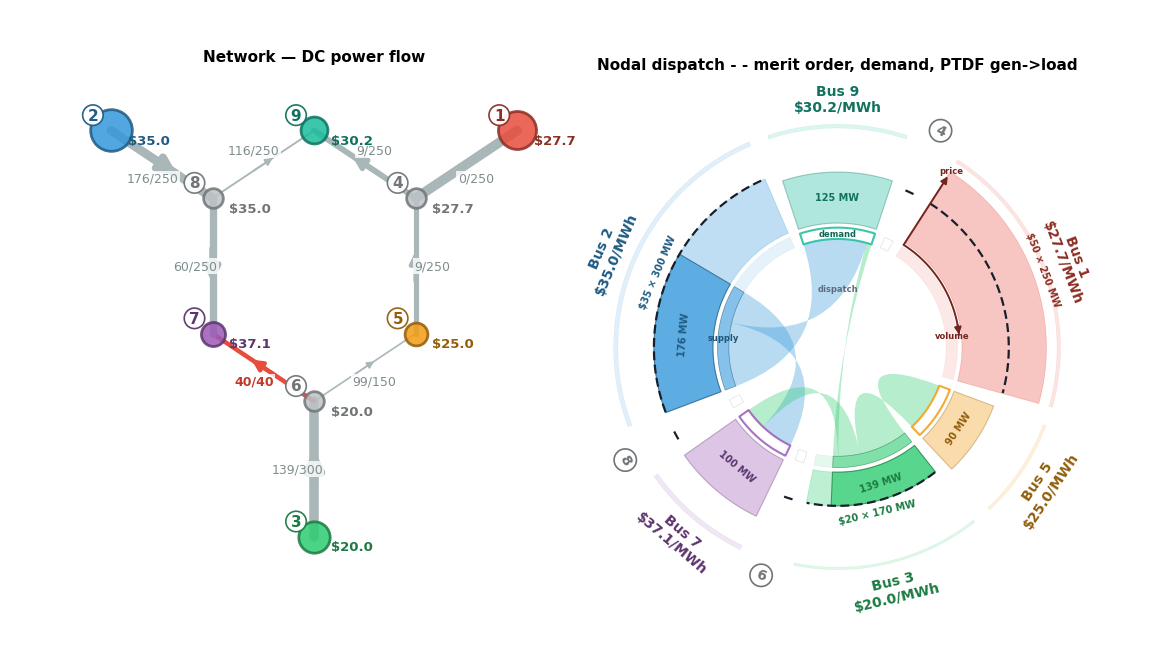

In [5]:
# The two-panel composite of the unified clearing: network DC power flow (left)
# and the nodal dispatch diagram (right). This is the set-up view; the BA split
# and allocation come next.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
    clearing_price=res.energy_price,
    demand_segments=shed_segments(res, dem),
    lmp_line=True, annotate_roles=True, axis_key=True,
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
plt.show()

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 2. Two market footprints on the shared network

The same 9-bus nodal network, now partitioned into **two market footprints**
that clear independently. Each market:

- optimises only its own generators against its own load (plus any scheduled interchange),
- enforces line limits only on its **own** computed flow component $F^M_m$,
  and only on the lines it monitors (its activated set $\mathcal M^M_{\mathrm{act}}$),
- treats the other market's dispatch as exogenous.

The footprints:

- **Market A** = buses {2, 8, 7, 6, 3} — the cheap fleet (gen_1 \$20 @ bus 3,
  gen_0 \$35 @ bus 2) and the load at bus 7 — the natural exporter.
- **Market B** = buses {1, 9, 4, 5} — only the expensive unit (gen_slack_0 \$50 @ bus 1)
  and the loads at buses 5 and 9 — the natural importer.

The partition leaves exactly two **seam lines** between the markets: `line_2`
(5-6) and `line_7` (8-9). Every other line is internal to one market. Formally the two markets are the
members of the engine set $\mathcal E=\{\mathrm{A},\mathrm{B}\}$ from the Section-2
nomenclature; each $M\in\mathcal E$ clears the Section-2 model over its own
$\mathcal R^M$, its own loads, and its own monitored-line set
$\mathcal M^M_{\mathrm{act}}$.

The partition assigns every **bus** to exactly one market. It does not assign
the **lines**. Which elements a market monitors is a separate design choice —
a market can monitor a tie, or a path inside its neighbour's footprint, and two
markets can monitor the same element — so the assignment can be ambiguous.
The config cell below makes the choice explicit: `MONITORED_LINES` lists each
market's $\mathcal M^M_{\mathrm{act}}$ **line by line**, so every assignment is
visible and editable. The natural default gives each market the lines with both
ends inside its footprint; the two seam lines are then placed explicitly —
`line_2` with **Market A** and `line_7` with **Market B**. Edit the lists to
move, share, or drop elements; a line in no market's set is monitored by
neither.

*Reading the figures below.* Lines are coloured by the market that monitors them
(Market A purple, Market B blue); a line stays grey when it sits in no market's
monitored set — or in both — and any line that turns bright red is overloaded,
which overrides its market colour.

In [6]:
## -- EDIT -- the two market footprints (buses) and each market's monitored lines.
MKT_DEFS = {
    'Market A': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'Market B': ['1', '9', '4', '5'],         # only the expensive bus-1 unit ($50); loads 5, 9 -> importer
}
MARKET_COLORS = {'Market A': '#993AFF', 'Market B': '#2471A3'}
# Each market's monitored set M^M_act. Every line listed explicitly; move a line,
# share it (list under both), or drop it (a line in no set draws grey).
MONITORED_LINES = {
    'Market A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = seam 5-6
    'Market B': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = seam 8-9
}
# ---------------------------------------------------------------------------
pt = shift_factors()
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='seam')

# Notebook aliases so the seam-issue cells below read naturally.
mkt_of = fp.fp_of
bus_to_mkt = fp.bus_to_fp
line_kind = lambda _pt, l: fp.line_kind(_pt, l)
seam_lines = fp.ties
monitored_by = lambda l: fp.monitored_by(l)
market_line_colors = lambda _pt: fp.line_colors(_pt)
MKT_GROUPS = fp.groups(pt)
internal = {m: [l for l in pt.lines if fp.line_kind(pt, l) == ('internal', m)] for m in MKT_DEFS}

A = make_engine('Market A', MKT_DEFS['Market A'], activated=MONITORED_LINES['Market A'])
B = make_engine('Market B', MKT_DEFS['Market B'], activated=MONITORED_LINES['Market B'])

print('Market A buses:', MKT_DEFS['Market A'], '| monitors:', MONITORED_LINES['Market A'])
print('Market B buses:', MKT_DEFS['Market B'], '| monitors:', MONITORED_LINES['Market B'])
print('seam lines:', seam_lines,
      '| monitored by neither:', [l for l in pt.lines if not monitored_by(l)] or 'none')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A buses:

['2', '8', '7', '6', '3']

| monitors:

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

...

['line_0', 'line_1', 'line_7', 'line_8']

seam lines:

['line_2', 'line_7']

| monitored by neither:

none

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


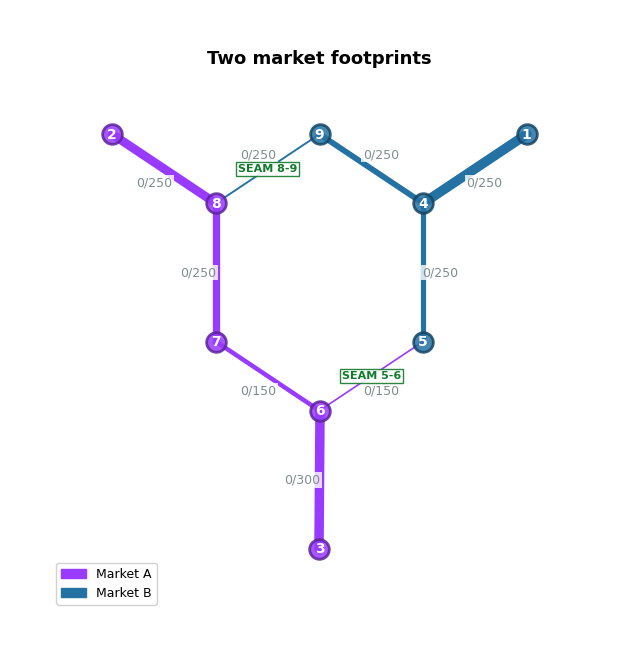

In [7]:
# Map of the two market footprints and the seam lines (buses coloured by market).
mkt_bus_colors = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=mkt_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt),   # lines coloured by the monitoring market; unmonitored grey
    title='Two market footprints',
)
for l in seam_lines:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'SEAM {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

In [8]:
# One market's clearing as a combined set (network + nodal dispatch), the other
# footprint greyed. Implemented by wscc9_figures.footprint_figure; bound to fp.
# A self-schedule (exo_sched) draws grey at the LMP (price-taking, not optimised);
# pass sup_dem to take full control of the bars (e.g. a dedicated trade block).
def market_figure(net_, pt_, eng, res, **kw):
    return figs.footprint_figure(net_, pt_, fp, eng, res,
                                 highlight=eng.name, shed=False, **kw)

print('market_figure bound (see wscc9_figures.py)')

market_figure bound (see wscc9_figures.py)

## 3. Seams issue 1 — dispatch interference

Each market clears on its own footprint with **no interchange scheduled**:
Market A serves its 100 MW load from its cheap units, Market B serves its
215 MW load from the bus-1 unit. Both clears are feasible, and both respect
every line limit they enforce. The wire still overloads.

`line_4` (6-7, internal to Market A) is rated at 40 MW, the same example limit
as Section 2. Market A holds its own flow at exactly 40. Market B's dispatch —
moving power from bus 1 to its loads at buses 5 and 9 — pushes a few extra MW
across line_4 on its way through the meshed network. Market B never looks:
line_4 is not in its monitored set $\mathcal M^B_{\mathrm{act}}$. The sum
exceeds the rating.

**Edit below:** the line ratings. Interference needs no interchange at all —
that is the point.

### The flow superposition behind the overload

Each market clears the model of Section 2 on its own footprint; the wire carries the sum.

**Each market's own flow — and what it ignores.**

$$F^M_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj},M}_n\qquad (m\in\mathcal M). \qquad\qquad(7)$$

*In words.* Market $M$'s computed flow sums shift factors against **only its own** injections.
The other market's injections contribute **zero** to $F^M_m$ even though their shift factors
are non-zero — the algebraic root of the interference.

**The physical flow is the superposition of both.**

$$F^{\mathrm{phys}}_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj,phys}}_n=\sum_{M\in\mathcal E}F^M_m\qquad (m\in\mathcal M). \qquad\qquad(8)$$

*In words.* By linearity of DC power flow, the flow that heats the wire is the sum of every
market's component — the `F_phys` column, identical to adding the `F[Market A]` and
`F[Market B]` columns (`physical_flows`).

**What each market enforces vs. what the wire enforces.**

$$\underbrace{\;|F^M_m|\le \bar F_m\ \ \forall M\in\mathcal E\;}_{\text{each market — its own component}}
  \qquad\Longrightarrow\!\!\!\!\!\diagup\qquad
  \underbrace{\;\Big|\textstyle\sum_{M\in\mathcal E} F^M_m\Big|\le \bar F_m\;}_{\text{the wire — the total}} \qquad\qquad(9)$$

*In words.* Each market keeps **its own** component within the rating, but nothing keeps
**their sum** within it — the left does not imply the right. When the two components share a
sign the physical flow can exceed the limit while every market reports a feasible,
within-limits dispatch: the `overload` column. No market-to-market reconciliation is running
here to bring the two clears into agreement before the wire does.

In [9]:
# -- EDIT -- ratings; then the two blind clears (no interchange) -----------
LINE_RATINGS = {'line_4': 40.0}   # the Section-2 limit, internal to Market A
# ---------------------------------------------------------------------------
net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

rA = solve_engine_dispatch(pt, A)   # no exo: zero scheduled interchange
rB = solve_engine_dispatch(pt, B)

print(f"Market A: dispatch { {g: round(v) for g, v in rA.dispatch.items()} }  energy ${rA.energy_price:.1f}/MWh  cost ${rA.total_cost:,.0f}")
print(f"Market B: dispatch { {g: round(v) for g, v in rB.dispatch.items()} }  energy ${rB.energy_price:.1f}/MWh  cost ${rB.total_cost:,.0f}")
print()
pf = physical_flows(pt, [rA, rB])
cols = ['from', 'to', 'F[Market A]', 'F[Market B]', 'F_phys', 'rating', 'loading_%', 'overload']
print("Line flows -- each market's own component vs the physical total:")
pf[cols]

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A: dispatch {'gen_0': 61, 'gen_1': 39}  energy $27.7/MWh  cost $2,909

Market B: dispatch {'gen_slack_0': 215}  energy $50.0/MWh  cost $10,750

Line flows -- each market's own component vs the physical total:

,from,to,F[Market A],F[Market B],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,0.0,215.0,215.0,250.0,86.0,False
line_1,4,5,0.6,93.4,94.0,250.0,38.0,False
line_2,5,6,0.6,3.4,4.0,150.0,3.0,False
line_3,3,6,39.4,-0.0,39.4,300.0,13.0,False
line_4,6,7,40.0,3.4,43.4,40.0,109.0,True
line_5,7,8,-60.0,3.4,-56.6,250.0,23.0,False
line_6,8,2,-60.6,0.0,-60.6,250.0,24.0,False
line_7,8,9,0.6,3.4,4.0,250.0,2.0,False
line_8,9,4,0.6,-121.6,-121.0,250.0,48.0,False


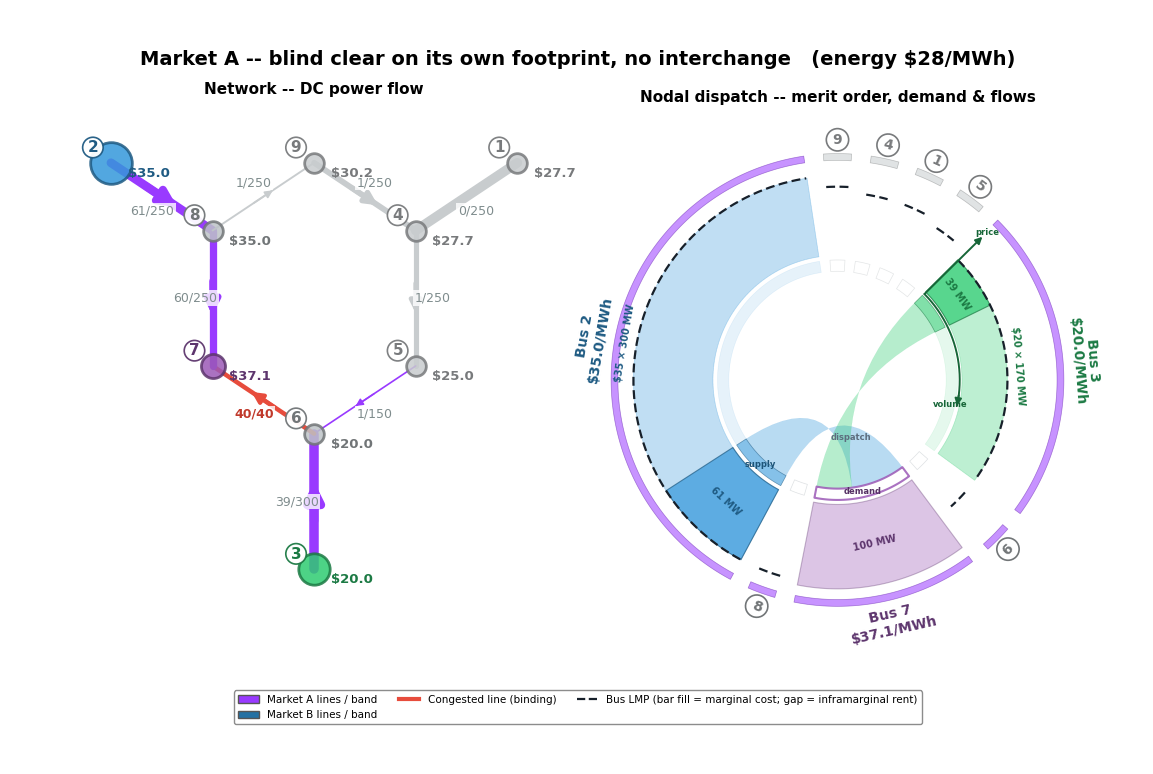

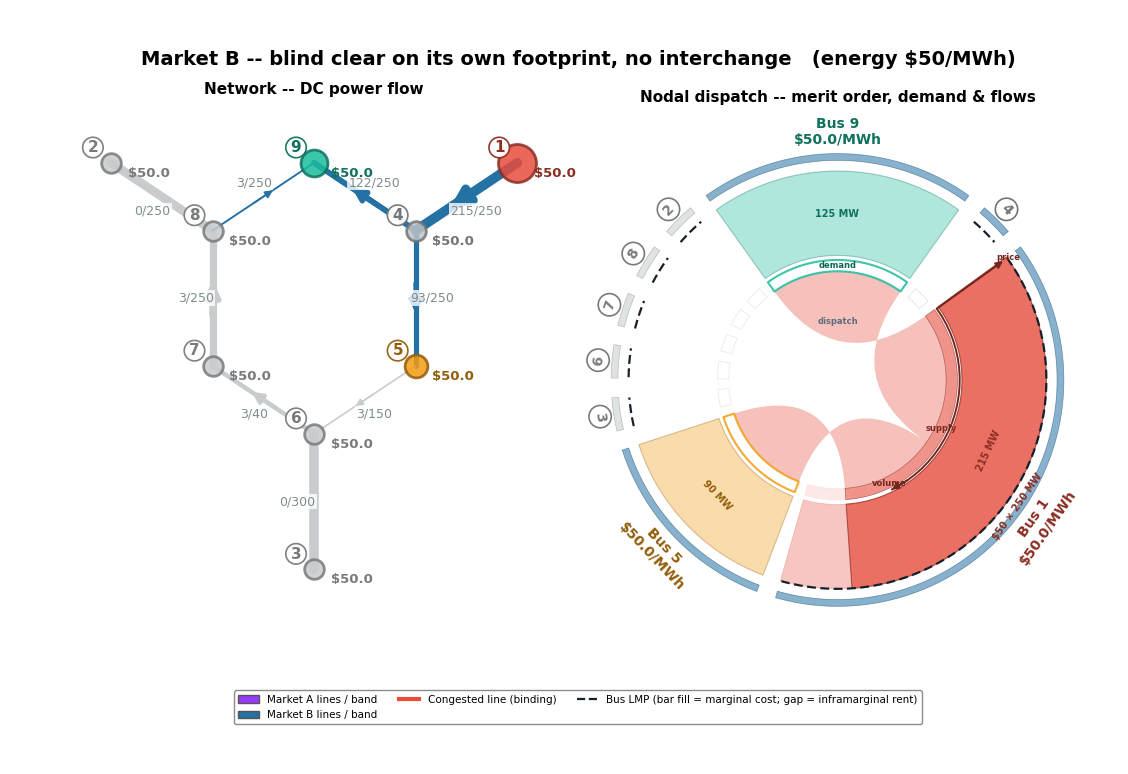

In [10]:
# Each market's blind clear as its own set: the network it dispatches and the
# merit order it prices. Both are internally feasible -- that is the trap.
for eng, r in ((A, rA), (B, rB)):
    market_figure(net, pt, eng, r,
        suptitle=f'{eng.name} -- blind clear on its own footprint, no interchange   '
                 f'(energy ${r.energy_price:.0f}/MWh)')
    plt.show()

In [11]:
ovl = pf[pf.overload]
if len(ovl):
    for ln, row in ovl.iterrows():
        a, b = row['F[Market A]'], row['F[Market B]']
        frm, to, rate, load = row['from'], row['to'], row['rating'], row['loading_%']
        print(f'[!] {ln} ({frm}-{to}): physical |{row.F_phys:.1f}| > {rate:.0f} MW rating ({load:.0f}%)')
        print(f'    Market A sees only {a:+.1f} MW, Market B sees only {b:+.1f} MW -- both within {rate:.0f}, '
              f'neither enforces the real limit.')
else:
    print('No overload at these settings -- tighten LINE_RATINGS.')

[!] line_4 (6-7): physical |43.4| > 40 MW rating (109%)

    Market A sees only +40.0 MW, Market B sees only +3.4 MW -- both within 40, neither enforces the real limit.

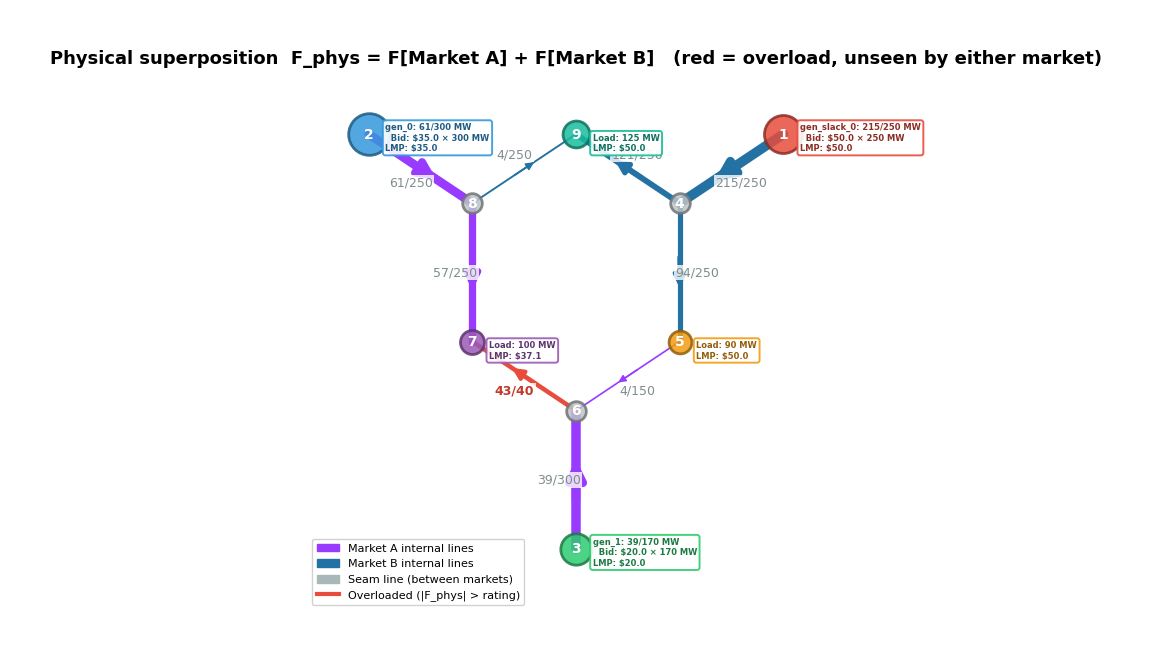

In [12]:
# Visual: physical superposition. Both markets' gens/loads on one map,
# line_flows = the PHYSICAL total. Width = susceptance; red = genuinely
# overloaded (|F_phys| > rating).
sup, dem = {}, {}
for eng, r in [(A, rA), (B, rB)]:
    s, d = to_supply_demand(eng, r); sup.update(s); dem.update(d)
# host LMP for annotation (host = the market that owns the bus)
host_lmp = {}
for r, eng in [(rA, A), (rB, B)]:
    for b in eng.buses: host_lmp[b] = r.lmp[b]
phys = {l: pf.loc[l, 'F_phys'] for l in pt.lines}
overloaded = set(pf[pf.overload].index)
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp, line_flows=phys,
    line_widths=susceptance_widths(pt), line_colors=market_line_colors(pt),
    constrained_lines=overloaded, bus_coords=COORDS,
    title='Physical superposition  F_phys = F[Market A] + F[Market B]   (red = overload, unseen by either market)',
)
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=f'{m} internal lines') for m in MARKET_COLORS]
          + [mpatches.Patch(color='#AAB7B8', label='Seam line (between markets)'),
             Line2D([0], [0], color='#E74C3C', lw=3, label='Overloaded (|F_phys| > rating)')],
          loc='lower left', fontsize=8, framealpha=0.9)
plt.show()

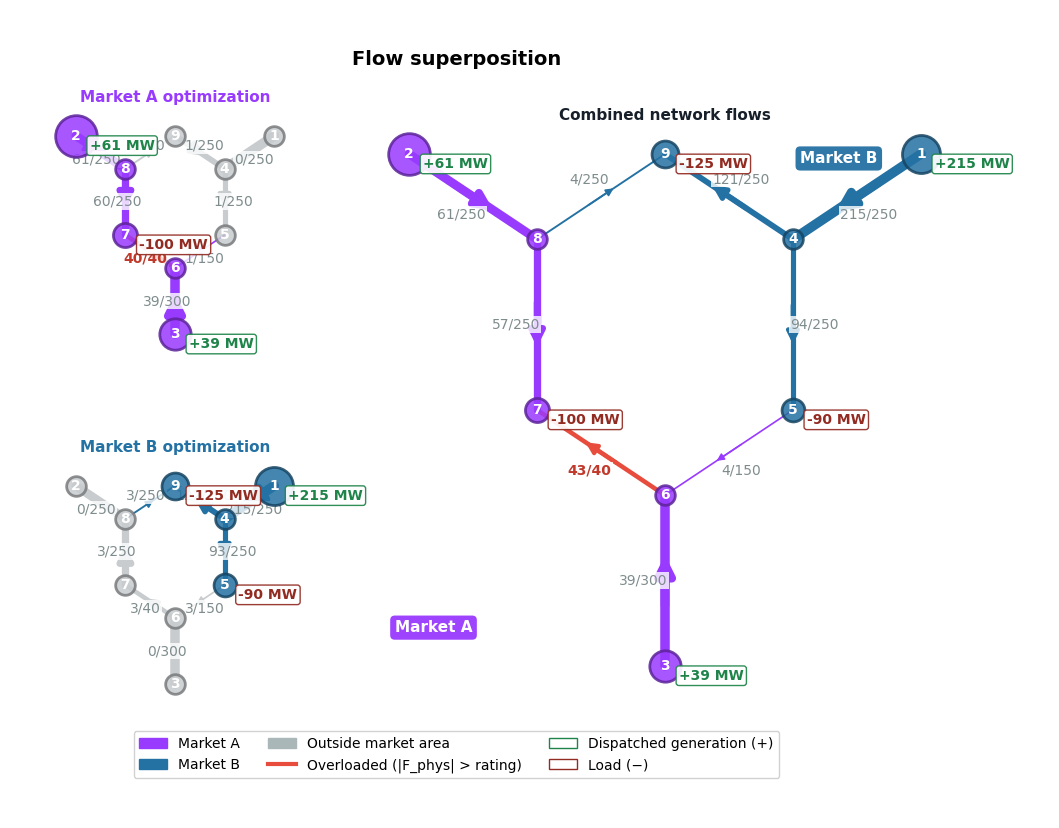

In [13]:
# Presentation (4:3 slide): flow superposition with NET INJECTION per bus instead
# of LMP -- dispatched generation (+), load (-). Nodes + lines coloured by MARKET
# (purple = Market A, blue = Market B; the other market greyed). Layout: Market A
# and Market B optimizations stacked on the LEFT, the combined physical flows on
# the RIGHT. The figure is sized to the slide (SLIDE_W x SLIDE_H inches) so
# matplotlib points == on-slide points: every label is >= BASE_PT (>= 10pt) when
# the image fills a 4:3 slide. (Place it full-bleed; if you shrink it, scale
# BASE_PT up by slide_inches / placed_inches.)
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

SLIDE_W, SLIDE_H = 10.0, 7.5         # 4:3 standard PowerPoint slide (inches)
BASE_PT = 10                         # minimum on-slide font size
PT_TITLE, PT_NUM, PT_FLOW = BASE_PT + 1, BASE_PT, BASE_PT
PT_INJ, PT_TAG, PT_LEGEND, PT_SUP = BASE_PT, BASE_PT + 1, BASE_PT, BASE_PT + 4
# Layout headroom. The stacked left panels are height-limited, so the network
# fills the panel top-to-bottom; LEFT_MARGIN shrinks it to keep the title off the
# top node and HSPACE separates the two panels. The tall combined panel is
# width-limited and needs little margin.
LEFT_MARGIN, COMBO_MARGIN, HSPACE = 0.13, 0.05, 0.40

_DIM = '#C8CCCE'
GEN_C, LOAD_C = '#1E8449', '#922B21'        # dispatched gen (+green), load (-maroon)

def net_injection(sup, dem):
    """{bus: signed MW} = dispatched generation (+) minus load (-)."""
    inj = {}
    for b, gens in sup.items():
        inj[b] = inj.get(b, 0.0) + sum(g['accepted_volume'] for g in gens)
    for b, d in dem.items():
        inj[b] = inj.get(b, 0.0) - d
    return inj

def inj_panel(ax, sup, dem, flows, *, highlight=None, constrained=None,
              title='', title_color='#17202A', margin=0.05):
    # nodes coloured by their market; lines by the monitoring market (seam grey)
    colors = {b: MARKET_COLORS[fp.fp_of(b)] for b in pt.buses}
    lcolors = market_line_colors(pt)
    if highlight is not None:                                   # grey the other market
        dim = {b for b in pt.buses if fp.fp_of(b) != highlight}
        for b in dim:
            colors[b] = _DIM
        dim_fps = {n for n in fp.names if all(str(b) in dim for b in fp.defs[n])}
        for l in pt.lines:
            i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
            if (b0 in dim and b1 in dim) or fp.line_assign.get(l) in dim_fps:
                lcolors[l] = _DIM
    plot_network_topology(
        net, sup, dem, bus_colors=colors, bus_coords=COORDS,
        line_flows=flows, line_widths=susceptance_widths(pt), line_colors=lcolors,
        constrained_lines=constrained, lmp_only=True,           # clean nodes, no LMP text
        title=title, ax=ax, number_position='inside',
        title_fontsize=PT_TITLE, node_number_fontsize=PT_NUM, flow_label_fontsize=PT_FLOW)
    ax.title.set_color(title_color)         # colour the title by market = the label
    ax.margins(margin)                      # headroom so the title clears the top node
    for b, mw in net_injection(sup, dem).items():               # +gen / -load labels
        if abs(mw) < 0.5 or b not in COORDS:
            continue
        if highlight is not None and fp.fp_of(b) != highlight:
            continue
        x, y = COORDS[b]
        ax.annotate(f'{mw:+.0f} MW', (x, y), fontsize=PT_INJ, fontweight='bold',
                    color=GEN_C if mw > 0 else LOAD_C,
                    xytext=(10, -10), textcoords='offset points', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white',
                              ec=(GEN_C if mw > 0 else LOAD_C), lw=1.0, alpha=0.92))
    # market tags: single-market panels carry the label in their coloured title,
    # so only the combined panel needs in-panel tags (one per cluster) to tell the
    # two colours apart.
    if highlight is None:
        for m, fx, fy, va in [(fp.names[0], 0.02, 0.10, 'bottom'),
                              (fp.names[1], 0.74, 0.96, 'top')]:
            ax.text(fx, fy, m, transform=ax.transAxes, fontsize=PT_TAG, fontweight='bold',
                    color='white', va=va, ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', fc=MARKET_COLORS[m], ec='none',
                              alpha=0.95), zorder=10)

supA, demA = to_supply_demand(A, rA)
supB, demB = to_supply_demand(B, rB)
supP, demP = {**supA, **supB}, {**demA, **demB}
phys = {l: pf.loc[l, 'F_phys'] for l in pt.lines}
overloaded = set(pf[pf.overload].index)
bindA = {l for l, mu in rA.line_dual.items() if abs(mu) > 1e-3}
bindB = {l for l, mu in rB.line_dual.items() if abs(mu) > 1e-3}

fig = plt.figure(figsize=(SLIDE_W, SLIDE_H))
gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.35], height_ratios=[1, 1],
                      hspace=HSPACE, wspace=0.0,
                      left=0.01, right=0.99, top=0.90, bottom=0.10)
axA = fig.add_subplot(gs[0, 0])     # Market A  (top-left)
axB = fig.add_subplot(gs[1, 0])     # Market B  (bottom-left)
axS = fig.add_subplot(gs[:, 1])     # Combined  (right, spans both rows)

inj_panel(axA, supA, demA, {l: rA.flow_own[l] for l in pt.lines},
          highlight='Market A', constrained=bindA, title='Market A optimization',
          title_color=MARKET_COLORS['Market A'], margin=LEFT_MARGIN)
inj_panel(axB, supB, demB, {l: rB.flow_own[l] for l in pt.lines},
          highlight='Market B', constrained=bindB, title='Market B optimization',
          title_color=MARKET_COLORS['Market B'], margin=LEFT_MARGIN)
inj_panel(axS, supP, demP, phys, constrained=overloaded, title='Combined network flows',
          margin=COMBO_MARGIN)

fig.legend(handles=[
    mpatches.Patch(color=MARKET_COLORS['Market A'], label='Market A'),
    mpatches.Patch(color=MARKET_COLORS['Market B'], label='Market B'),
    mpatches.Patch(color='#AAB7B8', label='Outside market area'),
    Line2D([0], [0], color='#E74C3C', lw=3, label='Overloaded (|F_phys| > rating)'),
    mpatches.Patch(fc='white', ec=GEN_C, label='Dispatched generation (+)'),
    mpatches.Patch(fc='white', ec=LOAD_C, label='Load (−)'),
], loc='lower center', ncol=3, fontsize=PT_LEGEND, framealpha=0.9,
   bbox_to_anchor=(0.5, 0.0))
fig.suptitle('Flow superposition', fontsize=PT_SUP, fontweight='bold')
plt.show()


**The point.** Market A's clear and Market B's clear both returned feasible,
within-limits solutions, with no interchange scheduled between them. Yet
`line_4` (6-7) carries ~43 MW on a 40 MW wire, because each market counted only
its own injections (eq. 7) and treated the other's flow as zero. A few MW of
unseen through-flow is all it takes once a line runs near its limit. No
market-to-market reconciliation is running here, so nothing reconciles the two
dispatches before the wire does.

## 4. Seams issue 2 — inefficient accommodation of flows

If Market B's flows cross Market A's wires, Market A can defend its limits by
**reserving room** for them: enforce each line it monitors not at its full rating,
but at the rating minus the flow it expects the other market to put there. This
is how Available Transfer Capability (ATC) methodologies work — transfer
capability is released to a market only after subtracting expected loop flow
plus a reliability margin.

The reservation restores feasibility, and that is its purpose. The cost is that
the reserved room is **exogenous**: it is fixed before the clear, sized from a
forecast of the other market's dispatch, and padded with a conservatism margin.
Reserve too little and the wire still overloads; reserve too much and
capability that the unified clearing would use sits idle.

### The reservation and the effective limit

**Each market enforces its limits with the other's expected flow already on the wire.**

$$-\bar F_m\le F^M_m+\widehat F^{M'}_m\le \bar F_m\qquad \forall\,m\in\mathcal M^M_{\mathrm{act}}. \qquad\qquad(10)$$

*In words.* Market $M$ checks each of its own lines against its own flow plus a fixed
estimate $\widehat F^{M'}_m$ of the other market's flow on that line. The estimate enters the
optimisation as a constant, not a decision variable (`flow_offsets`). The
reservation is made on the lines $M$ monitors — its activated set
$\mathcal M^M_{\mathrm{act}}$ from Section 3 — and $M'$ is the other market in
$\mathcal E$.

**The reservation is a reference flow times a margin.**

$$\widehat F^{M'}_m=\beta\,F^{M',\mathrm{ref}}_m\qquad (m\in\mathcal M^M_{\mathrm{act}}),\qquad \beta\ge 1. \qquad\qquad(11)$$

*In words.* The reference flow $F^{M',\mathrm{ref}}_m$ here is the other footprint's per-line
component in the unified clearing — the best available estimate of how the other market uses
the wire. The margin $\beta$ is the ATC-style conservatism (held distinct from the
risk-aversion coefficient $\gamma$ of Section 7): it protects against the estimate
being wrong, and its cost is capability withheld from the market.

In [14]:
# -- EDIT -- the reservation each market makes for the other's flows --------
ATC_MARGIN = 1.25    # beta: 1.0 = reserve exactly the reference flow
# ---------------------------------------------------------------------------

# Reference flow: each footprint's per-line component in the UNIFIED clearing.
uni_cong  = MarketEngine(name='unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                         loads=dict(LOADS), activated_lines='all')
runi_cong = solve_engine_dispatch(pt, uni_cong)
comp = {}
for m, buses in MKT_DEFS.items():
    p = np.zeros(pt.n_bus)
    for i, b in enumerate(pt.buses):
        if b in buses: p[i] = runi_cong.injection[i]
    comp[m] = pt.ptdf @ p

# The reservations: {line: signed MW} on each market's monitored lines.
# These are plain dicts -- override any entry to refine the rule.
ACCOMMODATION_A = {l: round(float(comp['Market B'][pt.line_idx[l]]) * ATC_MARGIN, 1)
                   for l in MONITORED_LINES['Market A']}
ACCOMMODATION_B = {l: round(float(comp['Market A'][pt.line_idx[l]]) * ATC_MARGIN, 1)
                   for l in MONITORED_LINES['Market B']}
print('Market A reserves (signed MW):', ACCOMMODATION_A)
print('Market B reserves (signed MW):', ACCOMMODATION_B)
print()

rA_acc = solve_engine_dispatch(pt, A, flow_offsets=ACCOMMODATION_A)
rB_acc = solve_engine_dispatch(pt, B, flow_offsets=ACCOMMODATION_B)
pf_acc = physical_flows(pt, [rA_acc, rB_acc])
print('overloads after accommodation:', pf_acc[pf_acc.overload].index.tolist() or 'none')
print()

rows = [
    {'arrangement': 'blind clears (issue 1)',
     'Market A cost': round(rA.total_cost), 'Market B cost': round(rB.total_cost),
     'sum': round(rA.total_cost + rB.total_cost), 'wire within limits': 'NO -- line_4 overloaded'},
    {'arrangement': f'accommodated (beta={ATC_MARGIN})',
     'Market A cost': round(rA_acc.total_cost), 'Market B cost': round(rB_acc.total_cost),
     'sum': round(rA_acc.total_cost + rB_acc.total_cost), 'wire within limits': 'yes'},
    {'arrangement': 'unified clearing',
     'Market A cost': '--', 'Market B cost': '--',
     'sum': round(runi_cong.total_cost), 'wire within limits': 'yes'},
]
pd.DataFrame(rows).set_index('arrangement')

Market A reserves (signed MW):

{'line_2': 4.3, 'line_3': -0.0, 'line_4': 4.3, 'line_5': 4.3, 'line_6': 0.0}

Market B reserves (signed MW):

{'line_0': -268.8, 'line_1': -128.0, 'line_7': 140.8, 'line_8': 140.8}

overloads after accommodation:

none

,Market A cost,Market B cost,sum,wire within limits
arrangement,,,,
blind clears (issue 1),2909,10750,13659,NO -- line_4 overloaded
accommodated (beta=1.25),2995,10750,13745,yes
unified clearing,--,--,8941,yes


In [15]:
# The price of conservatism: sweep the ATC margin and watch the cost climb.
rows = []
for g in [1.0, 1.25, 1.5, 2.0]:
    offA = {l: float(comp['Market B'][pt.line_idx[l]]) * g for l in MONITORED_LINES['Market A']}
    offB = {l: float(comp['Market A'][pt.line_idx[l]]) * g for l in MONITORED_LINES['Market B']}
    try:
        ra = solve_engine_dispatch(pt, A, flow_offsets=offA)
        rb = solve_engine_dispatch(pt, B, flow_offsets=offB)
        pfg = physical_flows(pt, [ra, rb])
        rows.append({'margin beta': g, 'sum cost': round(ra.total_cost + rb.total_cost),
                     'overloads': ', '.join(pfg[pfg.overload].index.tolist()) or 'none'})
    except RuntimeError:
        rows.append({'margin beta': g, 'sum cost': None, 'overloads': 'INFEASIBLE'})
lad = pd.DataFrame(rows).set_index('margin beta')
lad['extra vs beta=1.0'] = lad['sum cost'] - lad.loc[1.0, 'sum cost']
lad

,sum cost,overloads,extra vs beta=1.0
margin beta,,,
1.00,13728,none,0
1.25,13745,none,17
1.50,13762,none,34
2.00,13797,none,69


**Read it.** The accommodation works: the wire is safe, at a combined dispatch
cost a little above the blind clears and far above the unified clearing (the
remaining gap is the unrealised trade, taken up in Section 6). The margin
ladder prices the conservatism: every notch of $\beta$ moves Market A onto
dearer units to hold room it will almost never need. Notice the size of Market
B's reservations — the unified reference has Market A's generation serving the
whole system, so Market B holds room for flows far larger than anything in its
own dispatch: capability withheld, made visible. And the reservation is
only as good as its reference flow — it was computed from one snapshot of the
other market's dispatch. Change the loads or schedule an interchange and the
snapshot is stale: the wire can overload again with the reservation in place
(try it in the sandbox). Operations diverge from the schedule; a fixed
reservation cannot follow.

## 5. Seams issue 3 — participant-initiated interchange

No engine clears the seam. In the unified clearing, interchange between the
footprints is just dispatch — the optimisation moves cheap MW to expensive-to-serve load and
no one has to decide to trade. Between two markets, that flow happens only if a
**participant initiates it**: someone buys at A's seam bus, schedules a
transfer of $E$ MW across the seam, and sells at B's. From A's optimisation the
export is a firm withdrawal at its seam bus, and from B's optimisation it is a
fixed injection at its own seam bus — a **self-schedule**, fixed in advance
and frozen during the clear. A self-schedule carries no bid price, but it is
not invisible to the clearing: the export enters A as scheduled demand and
the import enters B as unpriced supply, so each market's residual supply
curve shifts and its clearing price can move. The schedule influences both
prices; it just never sets one.

Trade is what the seam is for: Market B's load is expensive to serve alone and
Market A has cheap spare capacity. Every scheduled MW saves the difference
between the two markets' marginal costs — the **seam dual gap** — and that
difference is the initiating participant's margin. But the schedule is
committed before the clear, so the participant earns the gap that
*materialises*, not the gap they expected. The first half of this section maps
what the trade turns out to be worth with perfect foresight; the second half
puts the uncertainty back and asks how much trade a risk-bearing participant
actually initiates.

For this section the line ratings revert to their base values, so the only
friction is the interchange itself.

### The self-scheduled interchange, the seam dual gap, and the cost of the seam

**The interchange is a decision for A but a frozen injection for B.**

$$p^{\mathrm{inj},A}_{n}\ \text{includes}\ -E\ \text{at A's seam bus},\qquad
  p^{\mathrm{inj},B}_{n}\ \text{includes}\ +E\ \text{at B's seam bus},\qquad
  \mathrm{exo}^M\ \text{fixed before the clear}. \qquad(12)$$

*In words.* From A the export $E$ is a withdrawal it optimises around; to B the same $E$ is a
fixed self-scheduled injection (`exo`). Plain italic $E$ is the scheduled interchange
quantity in MW — not the engine set $\mathcal E$ of the Section-2 nomenclature.
The self-schedule is not a bid volume: it enters B at the bottom of the supply
stack (unpriced supply — B's own generation backs down one-for-one and B's
marginal unit, hence B's LMP, can change) and enters A as scheduled demand
(A's marginal unit climbs its stack). It moves both clearing prices — what it
never does is set one, because it names no price.

**Each market prices the same bus through its own dispatch** (the nodal-LMP rule (5) of Section 2):

$$\lambda^A_n=\lambda^A+\!\!\sum_{m\in\mathcal M^A_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^A_m,
  \qquad\qquad
  \lambda^B_n=\lambda^B+\!\!\sum_{m\in\mathcal M^B_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^B_m. \qquad(13)$$

**Seam dual gap.**

$$\Delta\lambda^{A,B}_n:=\lambda^B_n-\lambda^A_n\ \neq\ 0\qquad (n\in\mathcal N;\ A,B\in\mathcal E). \qquad\qquad(14)$$

*In words.* The same physical megawatt carries two prices — one per market — and their
difference is generically non-zero **even though the network is shared**. Three things differ
between the markets: the marginal unit (disjoint resource stacks), the set of lines that
bind, and the load each serves. This is the `seam_dual_gap` column.

**The cost of the seam.**

$$W(E)=C^A(E)+C^B(E)-C^{\mathrm{unified}}\ \ge\ 0. \qquad\qquad(15)$$

*In words.* The cost of operating as two markets at interchange $E$ is the gap between the
sum of their independently optimised dispatch costs and the unified clearing's cost. Each
additional scheduled MW lowers $W$ at a rate equal to the seam dual gap at the interchange
buses — trade is worth exactly the price difference it closes — until the gap reaches zero
or the path is fully subscribed. The sweep below shows it: within each price plateau,
every step down in $W$ per MW equals the gap on that row (the row where a marginal unit
switches blends the two rates).

In [16]:
# -- EDIT -- the schedule: seam buses, the sweep, and a contract cap --------
EXPORT_BUS, IMPORT_BUS = '6', '5'     # across seam line_2 (5-6)
E_SWEEP         = [0, 25, 50, 75, 100, 125, 150, 175, 200, 215]
INTERCHANGE_CAP = 215.0               # contract/path cap on the schedule
# ---------------------------------------------------------------------------
net = build_network()                  # base ratings: the seam is the only friction
pt  = compute_ptdf(net, slack_bus='1')

uni  = MarketEngine(name='unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                    loads=dict(LOADS), activated_lines='all')
runi = solve_engine_dispatch(pt, uni)

rows, results = [], {}
for E in E_SWEEP:
    E = min(float(E), INTERCHANGE_CAP)
    rA_E = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -E} if E else None)
    rB_E = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +E} if E else None)
    results[E] = (rA_E, rB_E)
    gap = rB_E.lmp[IMPORT_BUS] - rA_E.lmp[EXPORT_BUS]
    sumC = rA_E.total_cost + rB_E.total_cost
    rows.append({'E (MW)': E,
                 'lambda_A(export)': round(rA_E.lmp[EXPORT_BUS], 1),
                 'lambda_B(import)': round(rB_E.lmp[IMPORT_BUS], 1),
                 'gap $/MWh': round(gap, 1),
                 'sum cost $': round(sumC),
                 'W(E) $': round(sumC - runi.total_cost)})
sweep = pd.DataFrame(rows).set_index('E (MW)')
print(f'unified clearing cost: ${runi.total_cost:,.0f}.')
print('Check the staircase: within each price plateau, each step down in W per MW equals the gap.')
print('(At E = 215 Market B has no unit left on the margin, so its reported price is a')
print(' degenerate 0 -- the economic gap has just closed.)')
sweep

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


unified clearing cost: $8,475.

Check the staircase: within each price plateau, each step down in W per MW equals the gap.

(At E = 215 Market B has no unit left on the margin, so its reported price is a

 degenerate 0 -- the economic gap has just closed.)

,lambda_A(export),lambda_B(import),gap $/MWh,sum cost $,W(E) $
E (MW),,,,,
0.0,20.0,50.0,30.0,12750,4275
25.0,20.0,50.0,30.0,12000,3525
50.0,20.0,50.0,30.0,11250,2775
75.0,35.0,50.0,15.0,10575,2100
100.0,35.0,50.0,15.0,10200,1725
125.0,35.0,50.0,15.0,9825,1350
150.0,35.0,50.0,15.0,9450,975
175.0,35.0,50.0,15.0,9075,600
200.0,35.0,50.0,15.0,8700,225


In [17]:
# The seam dual gap at every bus, at one operating point of the sweep.
E_SHOW = 150.0
rA_E, rB_E = results[E_SHOW]
gap = seam_dual_gap([rA_E, rB_E], pt.buses)
print(f'E = {E_SHOW:.0f} MW: each bus carries one price per market; the last column is the cross-market basis.')
gap

E = 150 MW: each bus carries one price per market; the last column is the cross-market basis.

,λ[Market A],λ[Market B],Δλ[Market A→Market B]
bus,,,
1,35.0,50.0,15.0
2,35.0,50.0,15.0
3,35.0,50.0,15.0
4,35.0,50.0,15.0
5,35.0,50.0,15.0
6,35.0,50.0,15.0
7,35.0,50.0,15.0
8,35.0,50.0,15.0
9,35.0,50.0,15.0


### One transaction, and who keeps the price difference

Make the trade concrete: a single participant-initiated transaction,
**sourced** at a Market A generator bus and **delivered** at a Market B load
bus, both configurable below. The schedule is physical, and **each market
carries its full path**: Market A's clear serves the delivery at the sink bus
($-E$ there, even though that bus sits outside A's footprint), and Market B's
clear receives the injection at the source bus ($+E$ there). Both markets'
network flows therefore show the same source$\to$sink routing, and each
market's monitored lines see the schedule's real loading.

Settlement is **four legs — two with each market**. Each market settles the
schedule across its full path, at its own LMPs at the two ends:

- **Market A buys the sourced MW** at its source-bus price $\lambda^A_s$ —
  exactly what it pays its generator there — **and sells the delivered MW**
  to the trader at its sink-bus price $\lambda^A_k$. A's books close, and the
  spread $(\lambda^A_k-\lambda^A_s)\,E$ — the congestion charge along the
  path through A — stays with Market A.
- **Market B buys the injected MW** from the trader at its source-bus price
  $\lambda^B_s$ **and sells it to the served load** at $\lambda^B_k$ (every
  MW of that load is billed the same $\lambda^B_k$). B's books close, and
  $(\lambda^B_k-\lambda^B_s)\,E$ stays with Market B.
- **The trader** pays $\lambda^A_k\,E$, is paid $\lambda^B_s\,E$, and keeps
  the **cross-market** difference $(\lambda^B_s-\lambda^A_k)\,E$ — eq. (14)'s
  gap, stretched between the delivery and receipt buses, with each market's
  internal congestion carved out.

The full source-to-sink price difference telescopes into the three positions:

$$\lambda^B_k-\lambda^A_s
  =\underbrace{(\lambda^A_k-\lambda^A_s)}_{\text{A's path congestion}}
  +\underbrace{(\lambda^B_s-\lambda^A_k)}_{\text{trader margin}}
  +\underbrace{(\lambda^B_k-\lambda^B_s)}_{\text{B's path congestion}}.$$

With no internal congestion the two market terms vanish and the trader
collects the whole gap. A binding constraint inside either market diverts
part of it into that market's congestion account — the wire's scarcity is
paid where it occurs, exactly as LMP settlement intends — and a contract
path that runs *against* a constraint makes its market's term negative.

All four prices are **endogenous**: they are the LMPs that materialise *with
the schedule in the clear*. A large enough schedule moves them — push $E$
past the cheap unit's spare capacity and Market A's own price rises,
thinning the trader's margin on every scheduled MW and re-pricing Market A's
own load along the way.

In the figures the grey volume is the transaction, and **every grey bar is
drawn at the *other* market's LMP for that bus** — which is exactly the
price the transaction settles at there: the four grey heights across the two
sets *are* the four settlement prices of the table below. The dashed line
marks each bus's own LMP (drawn across a split load bar too), so the vertical
distance between a grey bar and the dashed line is the seam dual gap at that
bus. In Market A's set the grey block leads the source generator's stack (a
self-schedule clears regardless of price), with the unit's remaining capacity
offered at its bid; in Market B's set the dedicated supply joins B's stack at
the greyed source bus and reaches B's loads through the shift factors, while
the grey slice of the sink load marks the MW the schedule serves. No panel
adds volume that does not exist; the bars in each balance.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


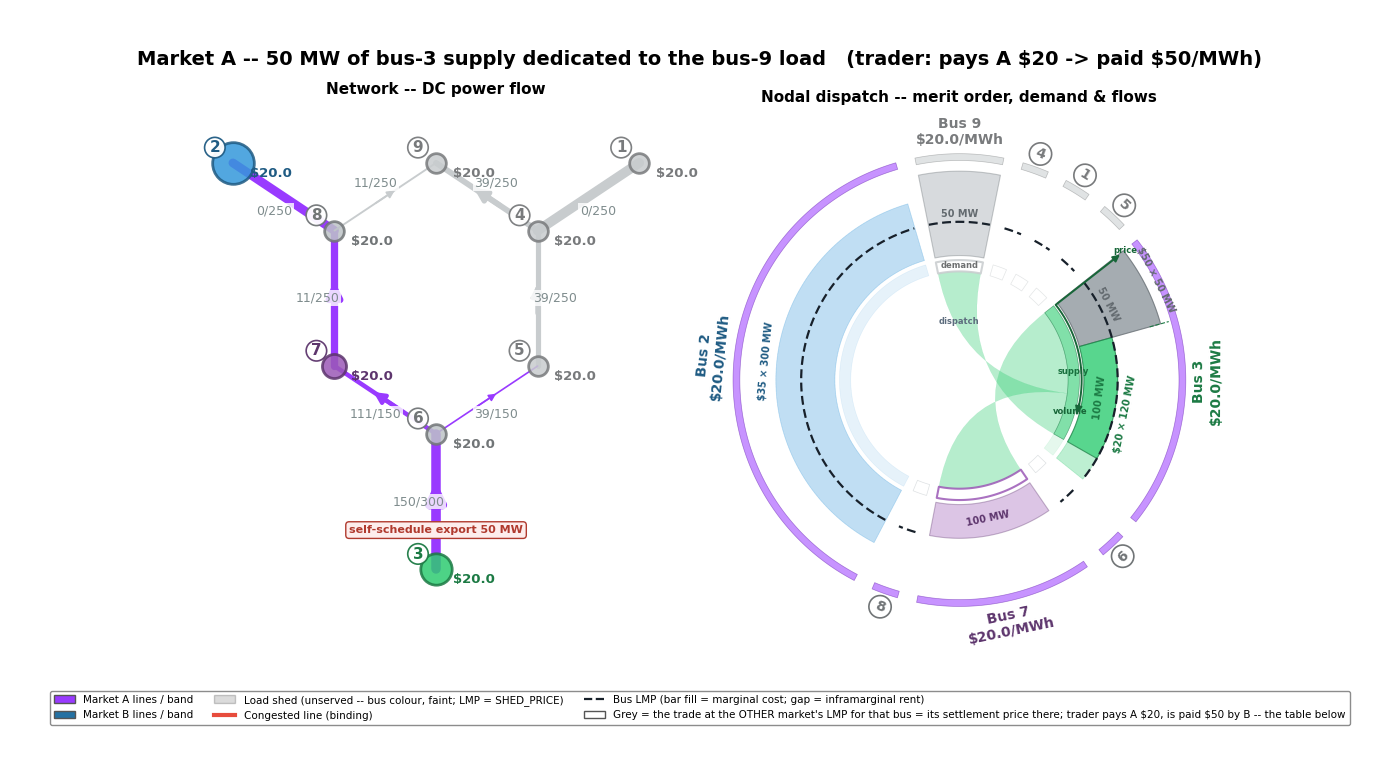

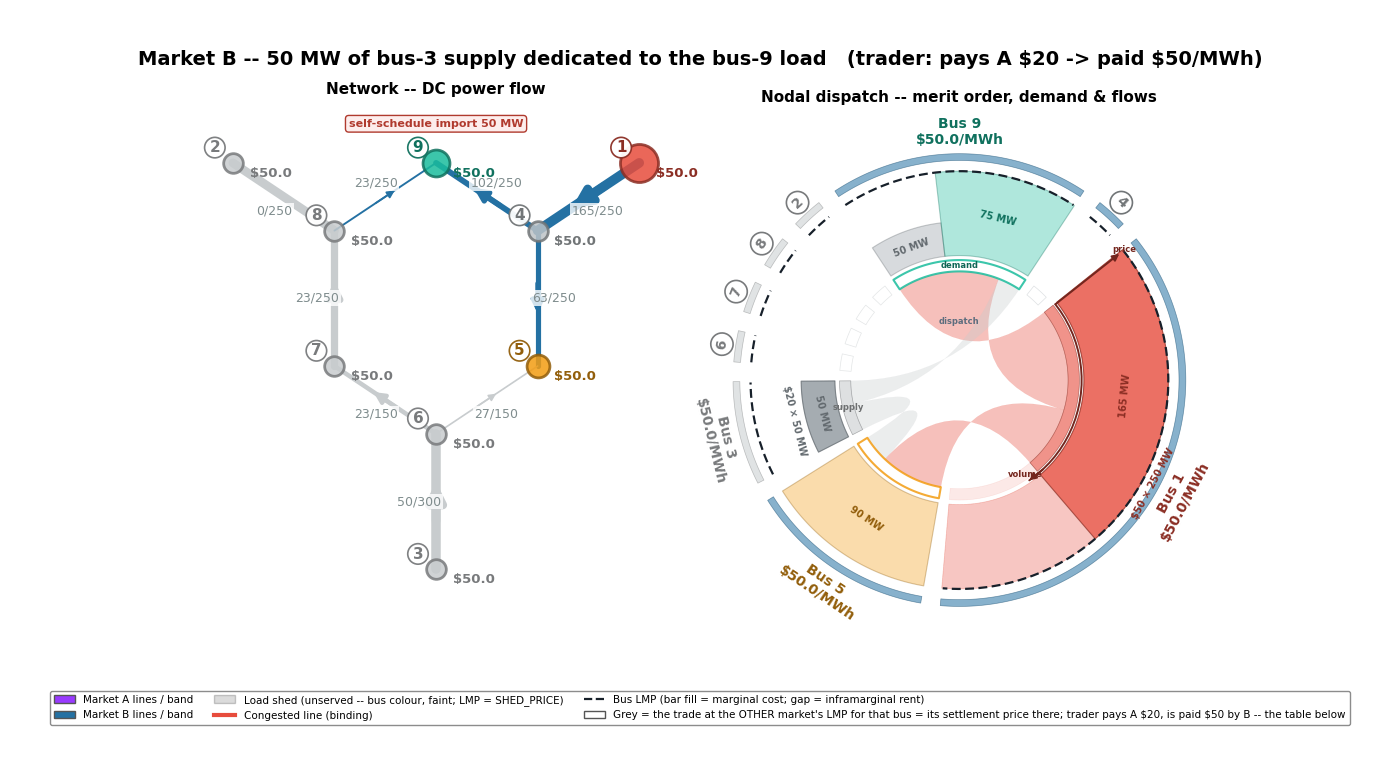

In [18]:
# -- EDIT -- the participant-initiated transaction ---------------------------
SOURCE_BUS = '3'      # sourced at a Market A generator bus
SINK_BUS   = '9'      # delivered at a Market B load bus
E_TRADE    = 50.0     # scheduled volume (MW)
TRADE_RATINGS = {}    # try {'line_4': 30.0} (and SOURCE_BUS '2'): congestion splits the gap
# -----------------------------------------------------------------------------
GRAY = '#8E979E'      # the transaction's colour -- it belongs to neither market
src_cap  = sum(s['p_nom'] for s in GEN_FLEET.values() if str(s['bus']) == SOURCE_BUS)
snk_load = float(LOADS.get(SINK_BUS, 0.0))
if E_TRADE > min(src_cap, snk_load):
    E_TRADE = min(src_cap, snk_load)
    print(f'E_TRADE clamped to {E_TRADE:.0f} MW '
          f'(source capacity {src_cap:.0f} MW, sink load {snk_load:.0f} MW).')

# Each market carries the schedule's FULL PATH: A's clear serves the delivery
# at the sink bus, B's clear receives the injection at the source bus -- so
# both network panels show the same source->sink routing.
net_T = build_network(TRADE_RATINGS)
pt_T  = compute_ptdf(net_T, slack_bus='1')
rA_T = solve_engine_dispatch(pt_T, A, exo={SINK_BUS: -E_TRADE})
rB_T = solve_engine_dispatch(pt_T, B, exo={SOURCE_BUS: +E_TRADE})
lamA_src, lamA_snk = rA_T.lmp[SOURCE_BUS], rA_T.lmp[SINK_BUS]   # Market A's two legs
lamB_src, lamB_snk = rB_T.lmp[SOURCE_BUS], rB_T.lmp[SINK_BUS]   # Market B's two legs

# The grey volume IS the transaction. EVERY grey bar is drawn at the OTHER
# market's LMP for that bus -- exactly the price the transaction settles
# at that bus (the four-leg table below). Market A's set: the source gen's
# stack STARTS with the grey block (a self-schedule clears regardless of
# price) at Market B's LMP for the source bus; the remaining capacity offers
# at its bid; the served load shows at the greyed sink bus at Market B's LMP
# there.
supA, demA = to_supply_demand(A, rA_T)
taken = 0.0
for u in supA.get(SOURCE_BUS, []):
    take = min(E_TRADE - taken, u['accepted_volume'])
    u['accepted_volume'] -= take
    u['volume'] = u['capacity'] = u['capacity'] - take
    taken += take
if taken < E_TRADE - 0.01:
    print(f'NOTE: the bus-{SOURCE_BUS} unit clears only {taken:.0f} of the '
          f'{E_TRADE:.0f} MW schedule in this dispatch.')
supA[SOURCE_BUS] = [u for u in supA.get(SOURCE_BUS, []) if u['volume'] > 0]
supA.setdefault(SOURCE_BUS, []).insert(0, {'unit_id': 'self_schedule',
                                           'price': rB_T.lmp[SOURCE_BUS],
                                           'volume': E_TRADE, 'capacity': E_TRADE,
                                           'accepted_volume': E_TRADE, 'color': GRAY})
demA[SINK_BUS] = demA.get(SINK_BUS, 0.0) + E_TRADE
segA = {SINK_BUS: [{'mw': E_TRADE, 'price': rB_T.lmp[SINK_BUS], 'color': GRAY}]}

# Market B's set (the mirror): the dedicated source gen joins B's stack at
# the (greyed) source bus -- at Market A's LMP for that bus -- and flows to
# B's loads through the shift factors; at the sink the load bar SPLITS: the
# grey first slice is the MW the schedule serves, drawn at Market A's LMP for
# the sink bus (every MW of the load is BILLED B's LMP; the grey height is
# the trader's delivery-leg price with Market A).
supB, demB = to_supply_demand(B, rB_T)
supB.setdefault(SOURCE_BUS, []).insert(0, {'unit_id': 'self_schedule',
                                           'price': rA_T.lmp[SOURCE_BUS],
                                           'volume': E_TRADE, 'capacity': E_TRADE,
                                           'accepted_volume': E_TRADE, 'color': GRAY})
segB = {SINK_BUS: [
    {'mw': E_TRADE, 'price': rA_T.lmp[SINK_BUS], 'color': GRAY},
    {'mw': demB[SINK_BUS] - E_TRADE, 'price': rB_T.lmp[SINK_BUS]},
]}

note = (f'Grey = the trade at the OTHER market\'s LMP for that bus = its settlement '
        f'price there; trader pays A \${lamA_snk:.0f}, is paid \${lamB_src:.0f} by B '
        f'-- the table below')
for eng, r, sd, segs, exo_s in (
    (A, rA_T, (supA, demA), segA, {SOURCE_BUS: -E_TRADE}),
    (B, rB_T, (supB, demB), segB, {SINK_BUS: +E_TRADE}),
):
    market_figure(net_T, pt_T, eng, r, sup_dem=sd, demand_segments=segs,
        exo_sched=exo_s, legend_note=note,
        suptitle=f'{eng.name} -- {E_TRADE:.0f} MW of bus-{SOURCE_BUS} supply dedicated '
                 f'to the bus-{SINK_BUS} load   (trader: pays A \${lamA_snk:.0f} -> paid \${lamB_src:.0f}/MWh)')
    plt.show()

In [19]:
# Four settlements. Each market settles the schedule across its FULL PATH at
# its own two LMPs: it buys the source at its source-bus LMP and sells the
# delivery at its sink-bus LMP. The trader sits between the two markets --
# pays A's delivery price, is paid B's receipt price -- and each market keeps
# its own path spread as a congestion charge. All four prices are endogenous
# (the LMPs that materialise WITH the schedule in the clear).
E = E_TRADE
legs = [
    ('Market A', f'buys source @ bus {SOURCE_BUS}', lamA_src, -lamA_src * E,
     'its generator (paid for the sourced MW)'),
    ('Market A', f'sells delivery @ bus {SINK_BUS}', lamA_snk, +lamA_snk * E,
     'the trader (charged at the delivery bus)'),
    ('Market B', f'buys injection @ bus {SOURCE_BUS}', lamB_src, -lamB_src * E,
     'the trader (paid at the receipt bus)'),
    ('Market B', f'sells to load @ bus {SINK_BUS}', lamB_snk, +lamB_snk * E,
     'the served load (billed like every other MW)'),
]
tbl = pd.DataFrame([{'market': m, 'leg': leg, 'settles at': f'${lam:.2f}',
                     'cash to market ($/h)': round(cash, 1), 'counterparty': who}
                    for m, leg, lam, cash, who in legs]).set_index(['market', 'leg'])
display(tbl)

split = pd.DataFrame([
    {'who keeps it': 'Market A -- path congestion',
     '$/h': round((lamA_snk - lamA_src) * E, 1),
     'formula': f'(lamA[{SINK_BUS}] - lamA[{SOURCE_BUS}]) x E'},
    {'who keeps it': 'Trader -- cross-market gap',
     '$/h': round((lamB_src - lamA_snk) * E, 1),
     'formula': f'(lamB[{SOURCE_BUS}] - lamA[{SINK_BUS}]) x E'},
    {'who keeps it': 'Market B -- path congestion',
     '$/h': round((lamB_snk - lamB_src) * E, 1),
     'formula': f'(lamB[{SINK_BUS}] - lamB[{SOURCE_BUS}]) x E'},
    {'who keeps it': 'TOTAL = full source-to-sink gap',
     '$/h': round((lamB_snk - lamA_src) * E, 1),
     'formula': f'(lamB[{SINK_BUS}] - lamA[{SOURCE_BUS}]) x E'},
]).set_index('who keeps it')
print(f'With the {E:.0f} MW schedule in the clear: '
      f'lamA[{SOURCE_BUS}] = ${lamA_src:.2f}, lamA[{SINK_BUS}] = ${lamA_snk:.2f}, '
      f'lamB[{SOURCE_BUS}] = ${lamB_src:.2f}, lamB[{SINK_BUS}] = ${lamB_snk:.2f}.')
print('Each market is whole leg-for-leg; the gap telescopes -- the three rows sum to the total:')
split

settles at  cash to market ($/h)                                  counterparty
market   leg                                                                                                  
Market A buys source @ bus 3        $20.00               -1000.0       its generator (paid for the sourced MW)
         sells delivery @ bus 9     $20.00                1000.0      the trader (charged at the delivery bus)
Market B buys injection @ bus 3     $50.00               -2500.0          the trader (paid at the receipt bus)
         sells to load @ bus 9      $50.00                2500.0  the served load (billed like every other MW)

With the 50 MW schedule in the clear: lamA[3] = $20.00, lamA[9] = $20.00, lamB[3] = $50.00, lamB[9] = $50.00.

Each market is whole leg-for-leg; the gap telescopes -- the three rows sum to the total:

,$/h,formula
who keeps it,,
Market A -- path congestion,0.0,(lamA[9] - lamA[3]) x E
Trader -- cross-market gap,1500.0,(lamB[3] - lamA[9]) x E
Market B -- path congestion,0.0,(lamB[9] - lamB[3]) x E
TOTAL = full source-to-sink gap,1500.0,(lamB[9] - lamA[3]) x E


**Read it:** with the 50 MW schedule in the clear every price is flat —
$\lambda^A=\$20$ across A's clear, $\lambda^B=\$50$ across B's — so both
congestion terms vanish and the trader keeps the whole gap: it pays Market A
\$20, is paid \$50 by Market B, and nets $(50-20)\times 50=\$1{,}500$/h. Each
market balances leg-for-leg: A charges the trader exactly what it pays its
generator, B pays the trader exactly what it bills the served load. The
prices are endogenous, and that disciplines the trade: raise `E_TRADE` to
125 (the clamp) and the schedule pushes Market A past its cheap unit —
$\lambda^A$ jumps to \$35, the margin thins to \$15/MWh, 2.5$\times$ the
volume earns only \$1,875/h, and Market A's own consumers pay \$1,500/h more
for their unchanged load: the schedule moved the very supply curve it was
arbitraging. Congestion **splits the gap instead of killing the trade**:
with `TRADE_RATINGS = {'line_4': 30.0}` the delivery price $\lambda^A_9$
rises to \$30.25 while bus 3 stays at \$20 behind the constraint, so Market A
keeps $(30.25-20)\times 50\approx\$512$/h as the congestion charge along the
path and the trader's margin thins to $\approx\$988$/h — the same \$1,500
gap, divided. Source the same 50 MW at bus 2 instead and the trader's
position does not move (it settles at the delivery and receipt buses): the
full bus-2$\to$9 gap is only \$750/h, yet the trader still nets \$988 — the
difference is Market A's term turning into a $-\$238$/h counterflow credit,
a contract path running against the constraint. *Where* the schedule sources
decides how much of the gap the source market keeps, not what the trader
earns. Tighten the line to 20 MW and the schedule is simply **infeasible**:
with the full path in A's clear, the wire cannot accommodate the trade at
all. Section 7 below prices exactly the trader's leg when the
endogenous LMPs are not known at commitment time.

**Settlement friction.** A megawatt sold by A and bought by B settles at A's
interface price on one side and B's on the other; with $\Delta\lambda_n\neq0$
the two need not net to the transaction's physical value. A *further* gap
arises at the interface itself, where a generator-weighted aggregation
(CAISO's GAP-Tie) and a load-weighted average (SPP's) summarise the same bus
prices differently — layering on top of this bus-level gap even when the
underlying $\lambda$'s agree.

### Where does the scheduled megawatt actually flow?

The schedule says $E$ MW leaves at bus 6 and arrives at bus 5 — a contract
path. The power itself leaves Market A's generators at buses 2 and 3 and
arrives at Market B's loads at buses 5 and 9, spreading over every parallel
path on the way. The two descriptions load the wires differently.

The cell below re-imposes the Section-4 limit (`line_4` = 40 MW) at $E$ = 150
and computes the flows both ways: once from the markets' scheduled injections
(the contract-path view each market enforces its limits against) and once from
the generators and loads alone (what the wires carry). Each market's own
component respects the limit, and even their scheduled-view sum understates
what the conductor actually carries, because the contract path injects the
transfer at the seam buses while the power actually comes from buses 2 and 3.
A constraint enforced against the contract path protects a fiction. This
transport-layer gap — BA-to-BA schedules standing in for bus-level physics —
is its own seams problem, beyond this notebook's scope.

In [20]:
# Contract-path view vs actual flows, with the Section-4 limit back in place.
E_CP = 150.0
pt_cp = compute_ptdf(build_network({'line_4': 40.0}), slack_bus='1')
rA_cp = solve_engine_dispatch(pt_cp, A, exo={EXPORT_BUS: -E_CP})
rB_cp = solve_engine_dispatch(pt_cp, B, exo={IMPORT_BUS: +E_CP})

# scheduled view: each market's injections, including the +-E at the seam buses
f_sched = pt_cp.ptdf @ (rA_cp.injection + rB_cp.injection)

# actual view: generators and loads only -- the transfer has no bus of its own
p_true = np.zeros(pt_cp.n_bus)
for r in (rA_cp, rB_cp):
    for b, mw in r.gen_by_bus.items():  p_true[pt_cp.bus_idx[b]] += mw
    for b, mw in r.load_by_bus.items(): p_true[pt_cp.bus_idx[b]] -= mw
f_true = pt_cp.ptdf @ p_true

cp = pd.DataFrame({
    'F[Market A]':    np.round([rA_cp.flow_own[l] for l in pt_cp.lines], 1),
    'F[Market B]':    np.round([rB_cp.flow_own[l] for l in pt_cp.lines], 1),
    'scheduled view': np.round(f_sched, 1),
    'actual view':    np.round(f_true, 1),
    'rating':         pt_cp.s_nom,
}, index=pt_cp.lines)
cp['actual overload'] = np.abs(cp['actual view']) > cp['rating'] + 1e-6
print(f'E = {E_CP:.0f} scheduled 6->5, line_4 rated 40 MW:')
cp

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


E = 150 scheduled 6->5, line_4 rated 40 MW:

,F[Market A],F[Market B],scheduled view,actual view,rating,actual overload
line_0,-0.0,65.0,65.0,65.0,250.0,False
line_1,5.5,-36.3,-30.8,6.7,250.0,False
line_2,5.5,23.7,29.2,-83.3,150.0,False
line_3,170.0,-0.0,170.0,170.0,300.0,False
line_4,25.5,23.7,49.2,86.7,40.0,True
line_5,-74.5,23.7,-50.8,-13.3,250.0,False
line_6,-80.0,0.0,-80.0,-80.0,250.0,False
line_7,5.5,23.7,29.2,66.7,250.0,False
line_8,5.5,-101.3,-95.8,-58.3,250.0,False


## 6. Initiating the trade means carrying the risk

The sweep above is a perfect-foresight map: it shows what each scheduled MW
*turned out* to be worth. The participant who initiates the trade never sees
that map. The schedule is fixed before the clear (eq. 12), so the trader
commits $E$ first and learns the prices after. What the trader holds is a
position whose payoff is the realised gap.

**The uncertainty model.** Two numbers are uncertain, one per market, and
they expose the trader to two different *kinds* of risk:

- **Market B's marginal cost** tomorrow is normally distributed around its
  posted cost, $c_B(\omega)\sim\mathcal N(50,\ \sigma_c^2)$. `gen_slack_0`
  is B's *only* unit, so its cost **is** B's entire (flat) supply curve and
  the whole bell passes straight through to $\lambda^B$: smooth **price
  risk**.
- **Market A's load** tomorrow is normally distributed around its forecast,
  $L_A(\omega)\sim\mathcal N(100,\ \sigma_L^2)$. A's stack is a staircase —
  \$20 for the first 170 MW, \$35 above — so what the trader does not know
  is **which side of A's step the schedule lands on**: $\lambda^A$ is a
  two-point mixture on $\{20,35\}$ whose weight
  $p_{35}(E)=\Pr[L_A+E>170]$ rises with every scheduled MW. Quantity risk
  becomes price risk *precisely because the schedule leans the market
  against its step*: a load draw moves B's price not at all (one flat
  unit), but it decides A's marginal unit exactly where the trade operates.

The basis the trader holds blends the two independent draws,
$\Delta\lambda=c_B-\lambda^A$ — a mixture of two bells. Three things happen
to it as $E$ grows (the figure below draws all three): the perfect-foresight
**staircase rounds into a glide** (some load draws put the schedule on the
expensive step well before $E=70$); the **spread bulges at the edge**
($\mathrm{sd}$ rises from \$15.5 to \$17.2 at $E=70$, where the step
coin-flip adds its variance); and the **loss tail thickens**. B's spread is
mean-preserving by construction; A's step risk is not a price assumption at
all — it is the geometry of the stack meeting an uncertain load. Set
`A_LOAD_SD = 0` and the model collapses back to a known staircase with B's
bell on top.

**The realised trading profit is a random payoff.**

$$\Pi(E,\omega)=\Delta\lambda^{A,B}(E,\omega)\cdot E\qquad(\omega\in\Omega). \qquad\qquad(16)$$

*In words.* $\Omega$ is the set of states the trader faces — here a
continuum, indexed by the pair (B's cost draw, A's load draw), independent
in this model; correlated fundamentals are the natural extension. The trader
pays Market A its price at the delivery bus and is paid Market B's price at
the receipt bus, both settled at the prices that materialise — the trader
leg of the four-part settlement above, here at the interchange buses (with
base ratings each market clears at one internal price, so the within-market
congestion terms vanish and the gap is the same for every source/sink pair).
Past the step the mean gap is \$15 against a \$15.5 spread: roughly one
outcome in six loses money.

**A risk-averse participant values the position below its expectation.**

$$\mathrm{CE}_\gamma(E)=\mathbb E_\omega\!\left[\Pi(E,\omega)\right]-\frac{\gamma}{2}\,\mathrm{Var}_\omega\!\left[\Pi(E,\omega)\right]. \qquad\qquad(17)$$

*In words.* The certainty equivalent: the sure payment the trader would accept in place of
the position. $\gamma\ge 0$ is the coefficient of risk aversion — $\gamma=0$ is
risk-neutral, and the subtracted variance term is the **risk premium**. (For exponential
utility and a normally distributed payoff this mean—variance form is *exact* — true here
whenever `A_LOAD_SD = 0`; with the step mixture switched on it is the standard
second-order treatment.)

**The initiated volume stops where the expected gap meets the risk premium.**

$$E^*(\gamma)=\arg\max_E\ \mathrm{CE}_\gamma(E);\qquad\text{within a price plateau}\quad
  \mathbb E_\omega\!\left[\Delta\lambda\right]=\gamma\,\sigma_{\Delta\lambda}^2\,E^*. \qquad\qquad(18)$$

*In words.* Trade until the expected gap equals the marginal risk premium
$\gamma\,\sigma^2 E$ — not until the gap closes. The premium grows with every MW already
at risk, so more uncertainty ($\sigma$) and more aversion ($\gamma$) both shrink the volume
the participant is willing to initiate. The unscheduled MWs are exactly the part of $W$ in
eq. (15) that stays on the table. This plateau rule is exact only *away* from A's step; near it
the glide re-prices every inframarginal MW and the variance bulges, so the
figures below read each $E^*$ straight off the certainty-equivalent curve
rather than from the closed form.

**Edit below:** the two spreads — $\sigma_c$ on B's cost, $\sigma_L$ on A's
load — and the risk-aversion ladder.

In [21]:
# -- EDIT -- what the participant cannot know when committing the schedule ---
B_COST_SD   = 15.5     # sd of Market B's marginal cost tomorrow ($/MWh); its
                       # mean is the posted $50. (15.5 = the sd of a 30/50/70
                       # spread w.p. .3/.4/.3 -- the discrete warm-up this
                       # continuous distribution generalises.)
A_LOAD_SD   = 15.0     # sd of Market A's load tomorrow (MW); mean = its 100.
                       # 0 switches A's step risk off: lamA is then a known
                       # staircase and only B's bell remains.
GAMMAS      = [0.0, 0.001, 0.005]   # risk aversion; 0 = risk-neutral
E_GRID  = list(range(0, 211, 5))    # candidate volumes (215 dropped: degenerate price)
N_NODES = 15           # Gauss-Hermite nodes for B's cost (deterministic integration)
QUANTS  = [0.05, 0.25, 0.50, 0.75, 0.95]    # fan-chart quantiles
# -----------------------------------------------------------------------------
from scipy.stats import norm
B_COST_MEAN = GEN_FLEET['gen_slack_0']['cost']
A_LOAD_BUS  = '7'
A_LOAD_MEAN = LOADS[A_LOAD_BUS]
zB, wB = np.polynomial.hermite_e.hermegauss(N_NODES)
wB = wB / wB.sum()                       # normal probability weights (sum to 1)
c_nodes = B_COST_MEAN + B_COST_SD * zB   # cost grid spanning B's bell
if A_LOAD_SD > 0:                        # clipped +-4 sd grid for A's load:
    zA = np.linspace(-4.0, 4.0, 33)      # bounded (no impossible-load tails),
    wA = np.exp(-zA ** 2 / 2)            # dense where the step risk lives
    wA = wA / wA.sum()
else:
    zA, wA = np.array([0.0]), np.array([1.0])
L_nodes = np.maximum(A_LOAD_MEAN + A_LOAD_SD * zA, 0.0)
E_arr = np.array(E_GRID, dtype=float)

# Market A re-clears at every load node: per E, lamA is a TWO-POINT MIXTURE --
# which side of A's step the schedule lands on depends on the load draw.
lamA  = np.zeros((len(L_nodes), len(E_GRID)))
costA = np.zeros_like(lamA)
for l, L in enumerate(L_nodes):
    A_l = make_engine('Market A', MKT_DEFS['Market A'],
                      activated=MONITORED_LINES['Market A'])
    A_l.loads[A_LOAD_BUS] = float(L)
    for j, E in enumerate(E_GRID):
        r = solve_engine_dispatch(pt, A_l, exo={EXPORT_BUS: -E} if E else None)
        lamA[l, j], costA[l, j] = r.lmp[EXPORT_BUS], r.total_cost

# Market B re-clears at every cost node: the bell passes through to lamB.
lamB  = np.zeros((N_NODES, len(E_GRID)))
costB = np.zeros_like(lamB)
for k, c in enumerate(c_nodes):
    B_k = make_engine('Market B', MKT_DEFS['Market B'],
                      activated=MONITORED_LINES['Market B'])
    B_k.gens['gen_slack_0']['cost'] = c
    for j, E in enumerate(E_GRID):
        r = solve_engine_dispatch(pt, B_k, exo={IMPORT_BUS: +E} if E else None)
        lamB[k, j], costB[k, j] = r.lmp[IMPORT_BUS], r.total_cost

# Unified benchmark at every (cost, load) pair, for the expected welfare loss.
cuni = np.zeros((N_NODES, len(L_nodes)))
for k, c in enumerate(c_nodes):
    for l, L in enumerate(L_nodes):
        uni_kl = MarketEngine(name='unified',
                              gens={g: dict(s) for g, s in GEN_FLEET.items()},
                              loads=dict(LOADS), activated_lines='all')
        uni_kl.gens['gen_slack_0']['cost'] = c
        uni_kl.loads[A_LOAD_BUS] = float(L)
        cuni[k, l] = solve_engine_dispatch(pt, uni_kl).total_cost

W2  = wB[:, None] * wA[None, :]              # joint weights (independent draws)
GAP = lamB[:, None, :] - lamA[None, :, :]    # the basis, (cost node, load node, E)
PI  = GAP * E_arr[None, None, :]             # the payoff
mu_gap = np.einsum('kl,klj->j', W2, GAP)
mu_pi  = np.einsum('kl,klj->j', W2, PI)
var_pi = np.einsum('kl,klj->j', W2, (PI - mu_pi) ** 2)
sd_gap = np.sqrt(np.einsum('kl,klj->j', W2, (GAP - mu_gap) ** 2))
EW = np.einsum('kl,klj->j', W2,
               costA[None, :, :] + costB[:, None, :] - cuni[:, :, None])
p_hi = wA @ (lamA > lamA.min() + 1e-6)       # P(schedule lands on A's expensive step)

# The basis distribution, analytically: conditional on the load draw the gap
# is normal in B's cost, so per E it is a MIXTURE of normals over the
# LP-cleared lamA atoms. Tails and quantiles come from this cdf -- the
# quadrature atoms are too coarse for 5% tails.
g_grid = np.linspace(B_COST_MEAN - lamA.max() - 5 * B_COST_SD,
                     B_COST_MEAN - lamA.min() + 5 * B_COST_SD, 800)
cdf = np.einsum('l,ljg->jg', wA,
                norm.cdf(g_grid[None, None, :],
                         loc=(B_COST_MEAN - lamA)[:, :, None], scale=B_COST_SD))
GAP_q = {q: np.array([np.interp(q, cdf[j], g_grid) for j in range(len(E_GRID))])
         for q in QUANTS}
PI_q = {q: GAP_q[q] * E_arr for q in QUANTS}
p_loss = np.einsum('l,lj->j', wA,
                   norm.cdf(0.0, loc=B_COST_MEAN - lamA, scale=B_COST_SD))

# Shared by every risk figure: one colour per gamma, and the volume each
# of the three modelled traders initiates (the argmax of its CE).
GAMMA_COLORS = ['#2E86C1', '#E67E22', '#27AE60']   # gamma 0 / 0.001 / 0.005
E_STAR = {g: E_GRID[int(np.argmax(mu_pi - 0.5 * g * var_pi))] for g in GAMMAS}

show = [0, 50, 70, 100, 150, 200]
idx = [E_GRID.index(e) for e in show]
gap_tbl = pd.DataFrame({f'gap q{int(q*100):02d}': GAP_q[q][idx].round(1)
                        for q in QUANTS},
                       index=pd.Index(show, name='E (MW)'))
gap_tbl['E[gap]'] = mu_gap[idx].round(1)
gap_tbl['sd[gap]'] = sd_gap[idx].round(2)
gap_tbl['P(lamA=35)'] = p_hi[idx].round(2)
gap_tbl['P(loss)'] = p_loss[idx].round(2)
print('The basis the trader is exposed to ($/MWh): quantiles, spread, and tails:')
display(gap_tbl)

rows = []
for g in GAMMAS:
    ce = mu_pi - 0.5 * g * var_pi
    k = int(np.argmax(ce))
    rows.append({'gamma': g, 'E* (MW)': E_GRID[k],
                 'E[profit] $': round(mu_pi[k]), 'sd[profit] $': round(np.sqrt(var_pi[k])),
                 'risk premium $': round(mu_pi[k] - ce[k]), 'CE $': round(ce[k]),
                 'E[gap @ E*]': round(mu_gap[k], 1), 'E[W @ E*] $': round(EW[k])})
print('The volume each trader initiates:')
pd.DataFrame(rows).set_index('gamma')

The basis the trader is exposed to ($/MWh): quantiles, spread, and tails:

,gap q05,gap q25,gap q50,gap q75,gap q95,E[gap],sd[gap],P(lamA=35),P(loss)
E (MW),,,,,,,,,
0,4.5,19.5,30.0,40.5,55.5,30.0,15.50,0.00,0.03
50,2.1,18.0,28.9,39.6,54.9,28.7,16.05,0.08,0.04
70,-5.1,11.6,23.3,35.0,51.4,23.2,17.20,0.45,0.09
100,-10.3,4.8,15.4,26.0,41.4,15.5,15.71,0.97,0.16
150,-10.5,4.5,15.0,25.5,40.5,15.0,15.50,1.00,0.17
200,-10.5,4.5,15.0,25.5,40.5,15.0,15.50,1.00,0.17


The volume each trader initiates:

,E* (MW),E[profit] $,sd[profit] $,risk premium $,CE $,E[gap @ E*],E[W @ E*] $
gamma,,,,,,,
0.000,210,3150,3255,0,3150,15.0,287
0.001,55,1543,896,402,1141,28.1,2855
0.005,25,750,388,376,374,30.0,3737


### What the trader faces: the induced price distributions

Two kinds of risk, one per market. Market A's price is a **two-point
mixture** — which side of its step the schedule lands on — and the first
panel tracks the two steps' outcome shares across the whole sweep: the more
the schedule leans on A's stack, the more probability mass sits on the \$35
step. Market B's price is the full **bell** of its uncertain cost. The third
panel draws the basis $\Delta\lambda=c_B-\lambda^A$ that each of the three
modelled traders actually holds **at its own chosen volume** $E^*(\gamma)$ —
B's bell mixed over A's two steps, weighted by the step shares. The
risk-neutral trader (largest volume) sits on the expensive step with the
lowest mean and the fattest loss tail; the more risk-averse traders stop
short of the step, where the basis is a tighter bell with little downside.
Each curve *looks* a smooth bell, but near A's step it is really a blend
of two — one per step — sitting only \$15 apart against a \$15.5 cost
spread; shrink `B_COST_SD` below ~\$7.5 and the two humps separate. The two draws are independent here; with both markets driven
by common fundamentals it is their *correlation* that would set the basis
spread.

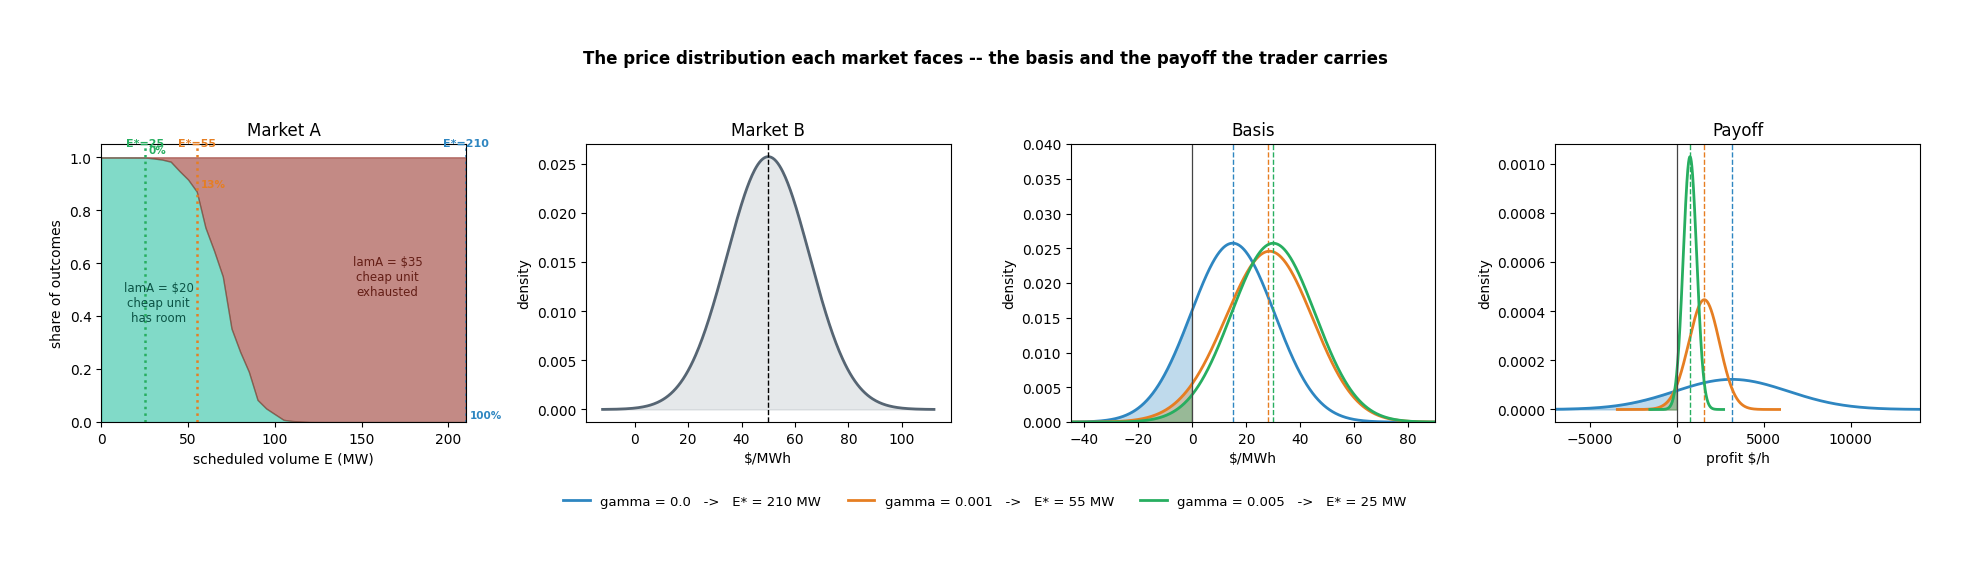

In [22]:
# The induced distributions, one colour per gamma (see the single legend
# below); per-trader statistics are in the table above, not repeated here.
# Market A: which side of A's step the schedule lands on -- a two-point
# mixture whose weights shift as E leans on A's stack. Market B: the cost
# bell. Basis: the per-MWh gap each modelled trader holds at its own
# E*(gamma). Payoff: that same basis scaled by E -- per-MWh risk is nearly
# identical at 25/55 MW, but the dollar distribution widens with volume, the
# exposure risk aversion trades off.
from matplotlib.lines import Line2D
SHOWN = [(g, E_STAR[g], c) for g, c in zip(GAMMAS, GAMMA_COLORS)]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.9))

ax = axes[0]
ax.fill_between(E_arr, 0, 1 - p_hi, color='#1ABC9C', alpha=0.55)
ax.fill_between(E_arr, 1 - p_hi, 1, color='#922B21', alpha=0.55)
ax.text(33, 0.45, 'lamA = \$20\ncheap unit\nhas room', ha='center', va='center',
        fontsize=8.5, color='#0B5345')
ax.text(165, 0.55, 'lamA = \$35\ncheap unit\nexhausted', ha='center', va='center',
        fontsize=8.5, color='#641E16')
for g, Es, c in SHOWN:
    j = E_GRID.index(Es)
    ax.axvline(Es, color=c, ls=':', lw=1.8)
    ax.annotate(f'E*={Es}', (Es, 1.04), color=c, fontsize=8, fontweight='bold',
                ha='center', annotation_clip=False)
    ax.annotate(f'{p_hi[j]:.0%}', (Es, 1 - p_hi[j]), xytext=(3, 3),
                textcoords='offset points', fontsize=7.5, color=c, fontweight='bold')
ax.set_xlim(0, 210); ax.set_ylim(0, 1.05)
ax.set_xlabel('scheduled volume E (MW)'); ax.set_ylabel('share of outcomes')
ax.set_title('Market A')

ax = axes[1]
xs = np.linspace(B_COST_MEAN - 4 * B_COST_SD, B_COST_MEAN + 4 * B_COST_SD, 400)
pdf_B = norm.pdf(xs, B_COST_MEAN, B_COST_SD)
ax.plot(xs, pdf_B, color='#566573', lw=2)
ax.fill_between(xs, pdf_B, color='#566573', alpha=0.15)
ax.axvline(B_COST_MEAN, color='k', ls='--', lw=1)
ax.set_xlabel('$/MWh'); ax.set_ylabel('density')
ax.set_title('Market B')

ax = axes[2]
for g, Es, c in SHOWN:
    j = E_GRID.index(Es)
    pdf_g = wA @ norm.pdf(g_grid[None, :],
                          loc=(B_COST_MEAN - lamA[:, j])[:, None], scale=B_COST_SD)
    ax.plot(g_grid, pdf_g, color=c, lw=2)
    ax.fill_between(g_grid[g_grid <= 0], pdf_g[g_grid <= 0], color=c, alpha=0.3)
    ax.axvline(mu_gap[j], color=c, ls='--', lw=1)
ax.axvline(0, color='#444', lw=0.9)
ax.set_xlim(-45, 90); ax.set_ylim(0, 0.040)
ax.set_xlabel('$/MWh'); ax.set_ylabel('density')
ax.set_title('Basis')

ax = axes[3]
for g, Es, c in SHOWN:
    j = E_GRID.index(Es)
    pdf_g = wA @ norm.pdf(g_grid[None, :],
                          loc=(B_COST_MEAN - lamA[:, j])[:, None], scale=B_COST_SD)
    pay    = g_grid * Es            # basis -> payoff: Pi = E * basis ($/h)
    pdf_pi = pdf_g / Es             # density of a deterministic scale: divide by E
    ax.plot(pay, pdf_pi, color=c, lw=2)
    ax.fill_between(pay[pay <= 0], pdf_pi[pay <= 0], color=c, alpha=0.3)
    ax.axvline(mu_pi[j], color=c, ls='--', lw=1)
ax.axvline(0, color='#444', lw=0.9)
ax.set_xlim(-7000, 14000)
ax.set_xlabel('profit $/h'); ax.set_ylabel('density')
ax.set_title('Payoff')

# the colours, labelled once
handles = [Line2D([0], [0], color=c, lw=2) for _, _, c in SHOWN]
labels  = [f'gamma = {g}   ->   E* = {Es} MW' for g, Es, _ in SHOWN]
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False,
           fontsize=9.5, bbox_to_anchor=(0.5, 0.02))

plt.suptitle('The price distribution each market faces -- the basis and the payoff the trader carries',
             fontweight='bold')
plt.tight_layout(rect=[0, 0.10, 1, 0.93])
plt.show()


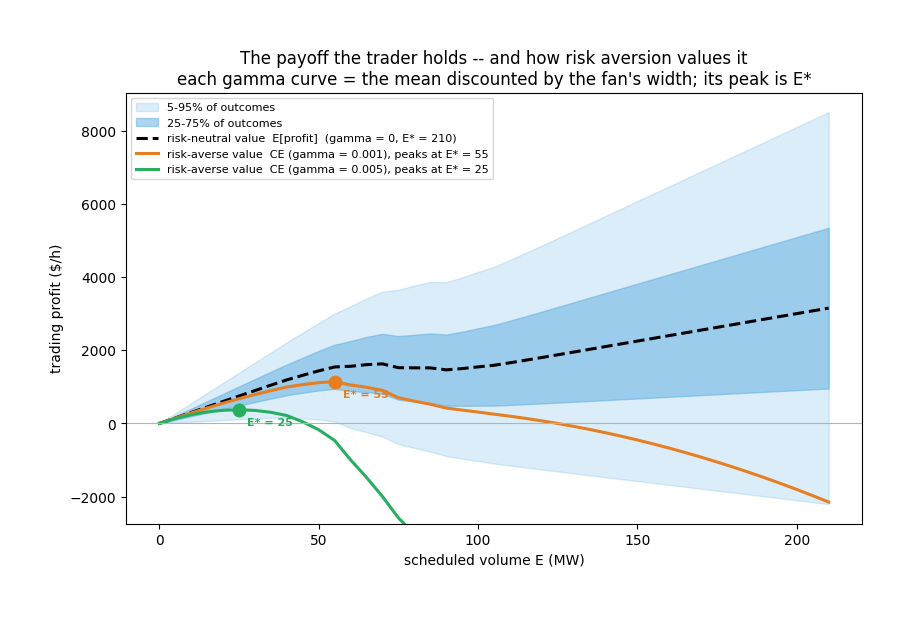

In [23]:
# The payoff the trader holds (the fan), with each trader's RISK-ADJUSTED
# value laid on top. CE_gamma(E) = the mean MINUS a penalty that grows with
# the fan's width, so a more risk-averse curve droops further below the
# dashed mean and peaks (its chosen volume E*) further left. Same gamma
# colours as the basis panel above.
fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.fill_between(E_arr, PI_q[0.05], PI_q[0.95], color='#5DADE2', alpha=0.22,
                label='5-95% of outcomes')
ax.fill_between(E_arr, PI_q[0.25], PI_q[0.75], color='#5DADE2', alpha=0.5,
                label='25-75% of outcomes')
ax.plot(E_arr, mu_pi, color='black', lw=2.2, ls='--',
        label='risk-neutral value  E[profit]  (gamma = 0, E* = 210)')
lo, hi = ax.get_ylim()                         # freeze the view to the fan
for g, c in zip(GAMMAS, GAMMA_COLORS):
    if g == 0:                                 # gamma = 0 IS the dashed mean
        continue
    ce = mu_pi - 0.5 * g * var_pi
    k = int(np.argmax(ce))
    ax.plot(E_arr, ce, color=c, lw=2.2,
            label=f'risk-averse value  CE (gamma = {g}), peaks at E* = {E_GRID[k]}')
    ax.plot([E_arr[k]], [ce[k]], 'o', color=c, ms=9, zorder=6)
    ax.annotate(f'E* = {E_GRID[k]}', (E_arr[k], ce[k]), xytext=(6, -11),
                textcoords='offset points', color=c, fontsize=8, fontweight='bold')
ax.axhline(0, color='#AAB7B8', lw=0.8)
ax.set_ylim(lo, hi)                            # the green CE plunges past the floor -- clip
ax.set_xlabel('scheduled volume E (MW)'); ax.set_ylabel('trading profit ($/h)')
ax.set_title('The payoff the trader holds -- and how risk aversion values it\n'
             "each gamma curve = the mean discounted by the fan's width; its peak is E*")
ax.legend(fontsize=8, loc='upper left')
plt.show()

**Read it:** B's spread is mean-preserving, but A's step risk is not
neutral: the expected gap **glides** from \$30 to \$15 as the schedule leans
harder on A's expensive step. The fan shows why the volume choice is not
simply "trade until the gap closes": the band of possible payoffs widens with
every scheduled MW, and a risk-averse trader values the position at the mean
*minus* a penalty for that width — each coloured curve is that risk-adjusted
value $\mathrm{CE}_\gamma$, and the trader initiates the volume where its own
curve **peaks**.

The three traders land in very different places, and the basis panel shows
the position each one actually carries at its chosen volume:

- The **risk-neutral** trader ($\gamma=0$) ignores the spread and pushes to
  $E^*=210$ MW — onto A's expensive step, where the basis is *worst*: mean
  just \$15, and about one outcome in six loses money. It books the largest
  expected profit (\$3,150/h, only ~\$287 of $W$ stranded) but holds the
  widest, most loss-prone position.
- A little aversion ($\gamma=0.001$) pulls the trader back to $E^*=55$ MW,
  just short of the step, where the basis mean is still ~\$28 and the loss
  tail is thin (CE \$1,141).
- A tail-wary trader ($\gamma=0.005$) stops at $E^*=25$ MW, deep on the cheap
  side ($p_{35}<1\%$): the basis is a tight bell around \$30 with almost no
  downside (CE \$374).

So risk aversion does not merely shrink the volume — it steers the trader
away from the part of the curve where the basis turns against them. The two
knobs separate cleanly: `B_COST_SD` scales the whole premium — double it and
every risk-averse $E^*$ collapses inward — while `A_LOAD_SD` acts *locally*,
bending the value where the schedule leans on A's step and barely touching
small schedules. That is the third seams issue in one line: **the seam turns
a dispatch decision into a risky position, and the risk premium — not the
wire — caps the trade.**

## 7. The seam ledger — who gains from closing the seam

Four arrangements on the base-ratings network, from no trade to full
integration: autarky ($E=0$), a capped schedule ($E=150$), a near-full schedule
($E=200$), and the unified clearing. For each, the ledger settles every market
at its own LMPs and asks who is better off than under autarky.

Conventions: consumers pay their market's LMP at their bus (shown negative);
generators earn their bus LMP minus marginal cost (producer surplus); the
exporter is paid its own seam-bus price for $E$ and the importer pays its own
seam-bus price for $E$ — the difference, the seam dual gap times $E$, accrues
to whoever holds the schedule (the **trader** column). $W$ is the
dispatch-cost excess over the unified clearing, eq. (15). The scheduled
volumes here are perfect-foresight choices; with the uncertainty of eqs.
(16)—(18) a risk-averse participant initiates less, so the trade rows are
upper bounds on what participant-initiated interchange delivers.

In [24]:
# Settle each arrangement at its own prices; positions vs autarky.
def positions(rA_E, rB_E, E):
    out = {}
    for m, r in [('Market A', rA_E), ('Market B', rB_E)]:
        loads_m = {b: LOADS[b] for b in MKT_DEFS[m] if b in LOADS}
        out[(m, 'consumers')] = -sum(r.lmp[b] * mw for b, mw in loads_m.items())
        out[(m, 'generators')] = sum(
            (r.lmp[str(GEN_FLEET[g]['bus'])] - GEN_FLEET[g]['cost']) * mw
            for g, mw in r.dispatch.items())
    out[('Trader', '')] = (rB_E.lmp[IMPORT_BUS] - rA_E.lmp[EXPORT_BUS]) * E
    cost = rA_E.total_cost + rB_E.total_cost
    out[('Total', 'production cost')] = -cost
    out[('Total', 'W vs unified')] = cost - runi.total_cost
    return out

def positions_unified(r):
    out = {}
    for m in MKT_DEFS:
        loads_m = {b: LOADS[b] for b in MKT_DEFS[m] if b in LOADS}
        out[(m, 'consumers')] = -sum(r.lmp[b] * mw for b, mw in loads_m.items())
        out[(m, 'generators')] = sum(
            (r.lmp[str(GEN_FLEET[g]['bus'])] - GEN_FLEET[g]['cost']) * mw
            for g, mw in r.dispatch.items() if str(GEN_FLEET[g]['bus']) in MKT_DEFS[m])
    out[('Trader', '')] = 0.0
    out[('Total', 'production cost')] = -r.total_cost
    out[('Total', 'W vs unified')] = 0.0
    return out

arrangements = {
    'autarky (E=0)':        positions(*results[0.0], 0.0),
    'capped trade (E=150)': positions(*results[150.0], 150.0),
    'near-full (E=200)':    positions(*results[200.0], 200.0),
    'unified clearing':     positions_unified(runi),
}
led = pd.DataFrame(arrangements).T.round(0)
led.columns = pd.MultiIndex.from_tuples(led.columns)
print('Positions ($/h; consumer payments negative):')
display(led)

party_cols = [c for c in led.columns if c[0] in ('Market A', 'Market B', 'Trader')]
delta = led[party_cols] - led[party_cols].loc['autarky (E=0)']
delta['Pareto vs autarky'] = (delta[party_cols] >= -1e-6).all(axis=1).map({True: 'yes', False: 'NO'})
print('Change vs autarky (who gains, who loses):')
delta

Positions ($/h; consumer payments negative):

Market A             Market B             Trader           Total             
                     consumers generators consumers generators         production cost W vs unified
autarky (E=0)          -2000.0        0.0  -10750.0        0.0     0.0        -12750.0       4275.0
capped trade (E=150)   -3500.0     2550.0  -10750.0        0.0  2250.0         -9450.0        975.0
near-full (E=200)      -3500.0     2550.0  -10750.0        0.0  3000.0         -8700.0        225.0
unified clearing       -3500.0     2550.0   -7525.0        0.0     0.0         -8475.0          0.0

Change vs autarky (who gains, who loses):

Market A             Market B             Trader Pareto vs autarky
                     consumers generators consumers generators                          
autarky (E=0)              0.0        0.0       0.0        0.0     0.0               yes
capped trade (E=150)   -1500.0     2550.0       0.0        0.0  2250.0                NO
near-full (E=200)      -1500.0     2550.0       0.0        0.0  3000.0                NO
unified clearing       -1500.0     2550.0    3225.0        0.0     0.0                NO

**Read it.** Trade shrinks the production-cost bill monotonically — $W$ falls
to zero at the unified clearing — but the gains land unevenly, and where they
land depends on the arrangement. Under the scheduled trades, Market B's
consumers gain nothing at all: the import settles at Market B's own marginal
price, still set by the bus-1 unit, so the entire trade surplus accrues to
Market A's generators and the trader holding the schedule. Only the unified
clearing passes the cheap generation through to Market B's load (its price
falls from \$50 to \$35). Market A's consumers lose in every arrangement:
exporting raises their own price from \$20 to \$35, the classic
exporting-region distributional result. Integration is efficient in total and
not automatically a Pareto improvement — making every party whole takes a side
instrument (contracts for differences, congestion-revenue rights, or an agreed
allocation of the trade surplus), which is a design choice the dispatch itself
does not make.

## 8. Sandbox

One cell, every knob. Reassign buses to markets, change which constraints
each market *activates* (`activated_lines` = the discretionary set
$\mathcal M^M_{\text{act}}$), schedule a seam interchange, route a
**participant-initiated trade** (source bus, sink bus, volume — full-path,
four-leg settlement, and grey cross-valuation bars, the Section-6
conventions), re-bid units, and switch the accommodation on or off. Re-run to
see prices, the dual gap, the trader's settlement, and a **Section-8-style
positions ledger against autarky and the unified clearing** (consumer
payments, generator revenue and profit shown separately, each market's
**congestion revenue** — its settlement residual, so every row closes:
consumers = gen revenue + congestion + trader — the trader's profit,
production cost, and the seam cost $W$ of eq. (15); in the unified row the
pool's rent is attributed to the footprint containing each binding line,
which is itself an allocation choice). Autarky re-clears the same knobs with every cross-boundary
schedule removed — no interchange, no trade — so nothing settles across the
boundary. Flows and overloads are the
**actual** wire loading — generators and loads counted once; a schedule
booked in both clears has no bus of its own, so the booked sum
$F^A_m+F^B_m$ would re-count its path. Then the figures: each market's
[network + nodal dispatch] set, a **combined set** of the actual total flows
with every bus priced at its home market's LMP, and the **unified clearing's
own set** — the one-engine benchmark every seam construct is measured
against. The sandbox rewires the Section-3 footprint config for its figures
— re-run Section 3 to restore the defaults.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


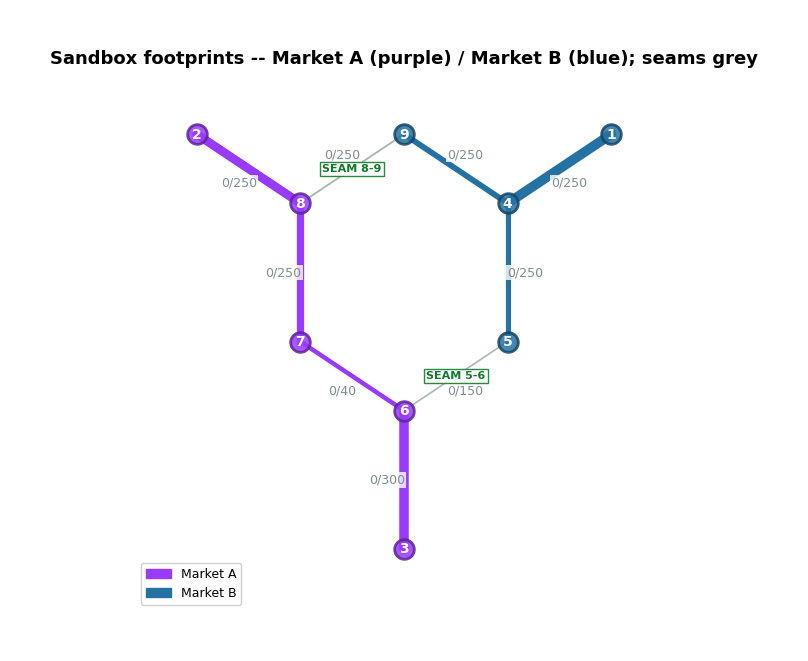

A energy

27.7

| B energy

50.0

overloads (actual):

...

,λ[Market A],λ[Market B],Δλ[Market A→Market B]
bus,,,
1,27.74,50.0,22.26
2,35.00,50.0,15.00
3,20.00,50.0,30.00
4,27.74,50.0,22.26
5,25.02,50.0,24.98
6,20.00,50.0,30.00
7,37.13,50.0,12.87
8,35.00,50.0,15.00
9,30.25,50.0,19.75


,from,to,F[Market A],F[Market B],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,-0.0,165.0,165.0,250.0,66.0,False
line_1,4,5,-15.3,62.7,71.9,250.0,29.0,False
line_2,5,6,-15.3,-27.3,-18.1,150.0,12.0,False
line_3,3,6,55.3,50.0,55.3,300.0,18.0,False
line_4,6,7,40.0,22.7,37.2,40.0,93.0,False
line_5,7,8,-60.0,22.7,-62.8,250.0,25.0,False
line_6,8,2,-94.7,0.0,-94.7,250.0,38.0,False
line_7,8,9,34.7,22.7,31.9,250.0,13.0,False
line_8,9,4,-15.3,-102.3,-93.1,250.0,37.0,False


Positions ($/h; consumer payments negative):

actual overloads -- autarky: ['line_4'] | sandbox: none | unified: none

Market A                                            Market B                                           Trader  \
                                     consumers gen revenue gen profit congestion revenue consumers gen revenue gen profit congestion revenue profit   
autarky (no cross-boundary schedule)   -3713.0      2909.0        0.0              804.0  -10750.0     10750.0        0.0                0.0    0.0   
sandbox arrangement (knobs above)      -3713.0      4421.0        0.0              804.0  -10750.0      8250.0        0.0                0.0  988.0   
unified clearing                       -3713.0      8941.0        0.0              804.0   -6033.0         0.0        0.0                0.0    0.0   

                                               Total               
                                     production cost W vs unified  
autarky (no cross-boundary schedule)        -13659.0       4717.0  
sandbox arrangement (knobs above)           -12671.0       3730.0  
unified clearing                             -8941.0          0.0

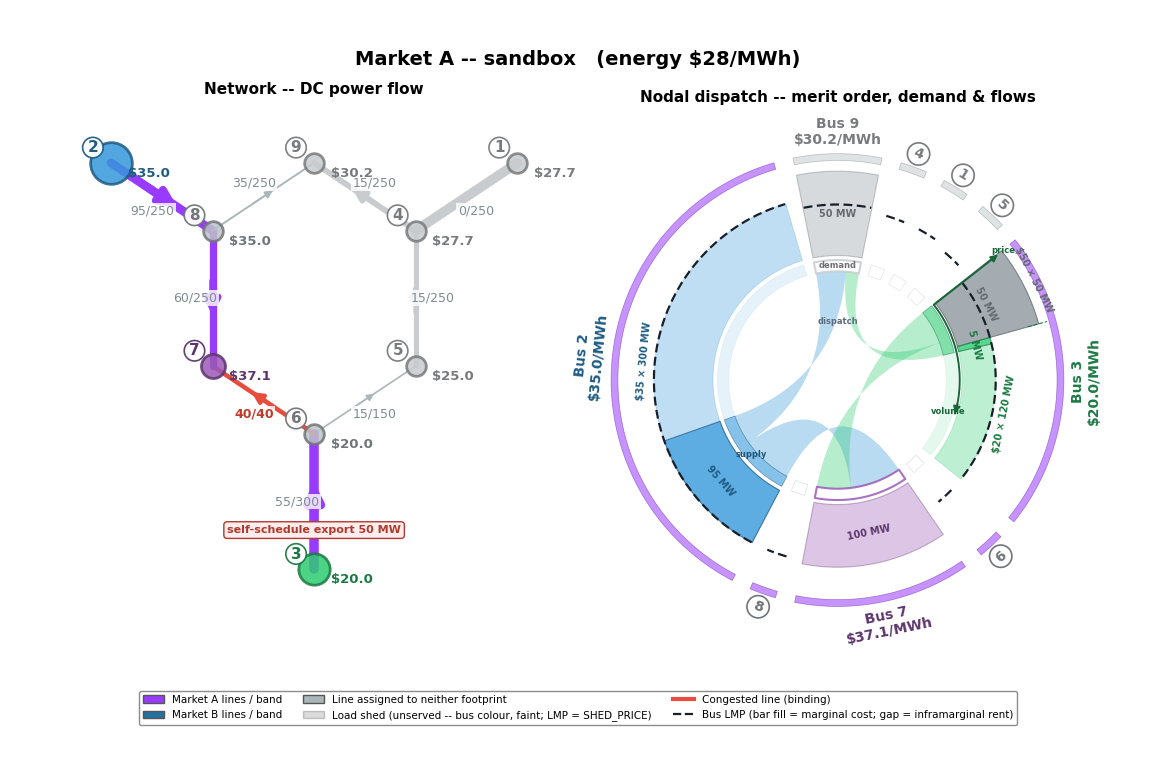

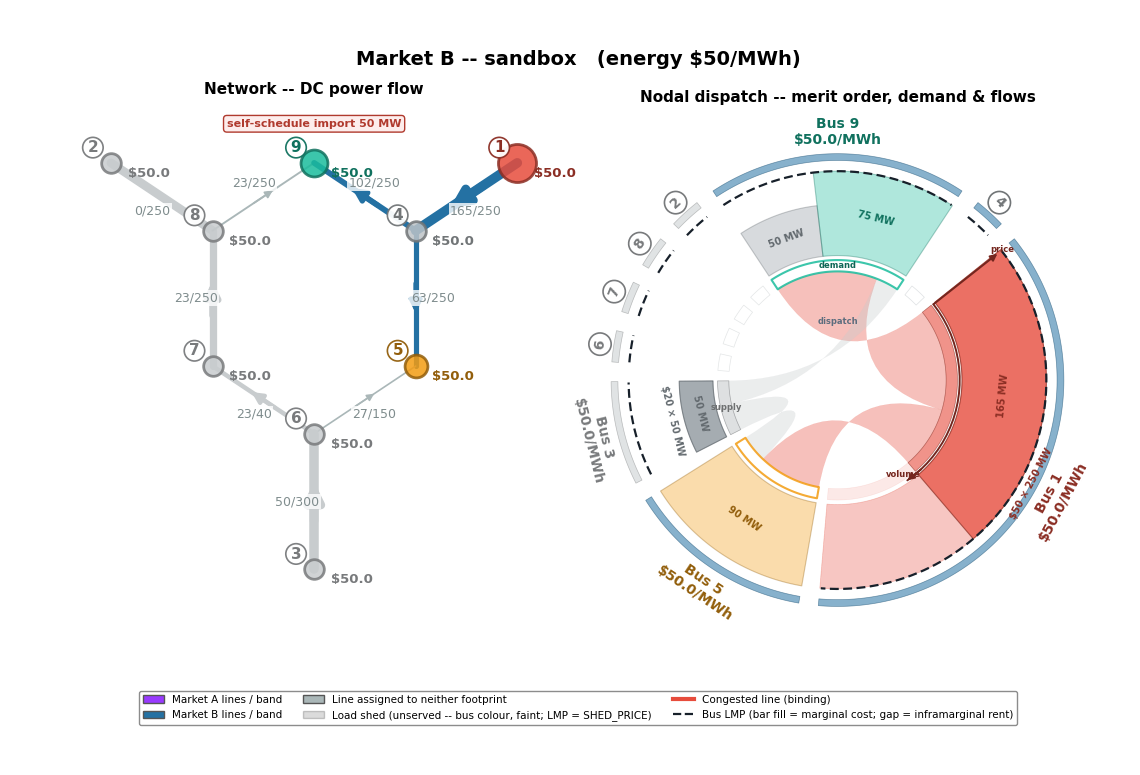

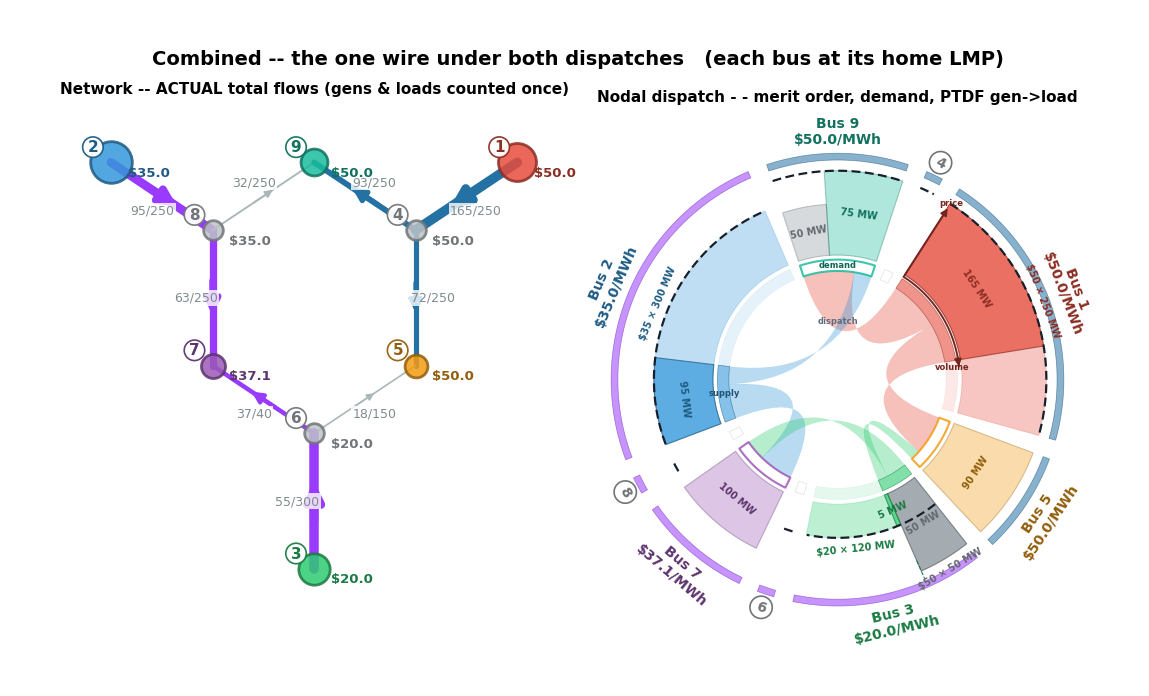

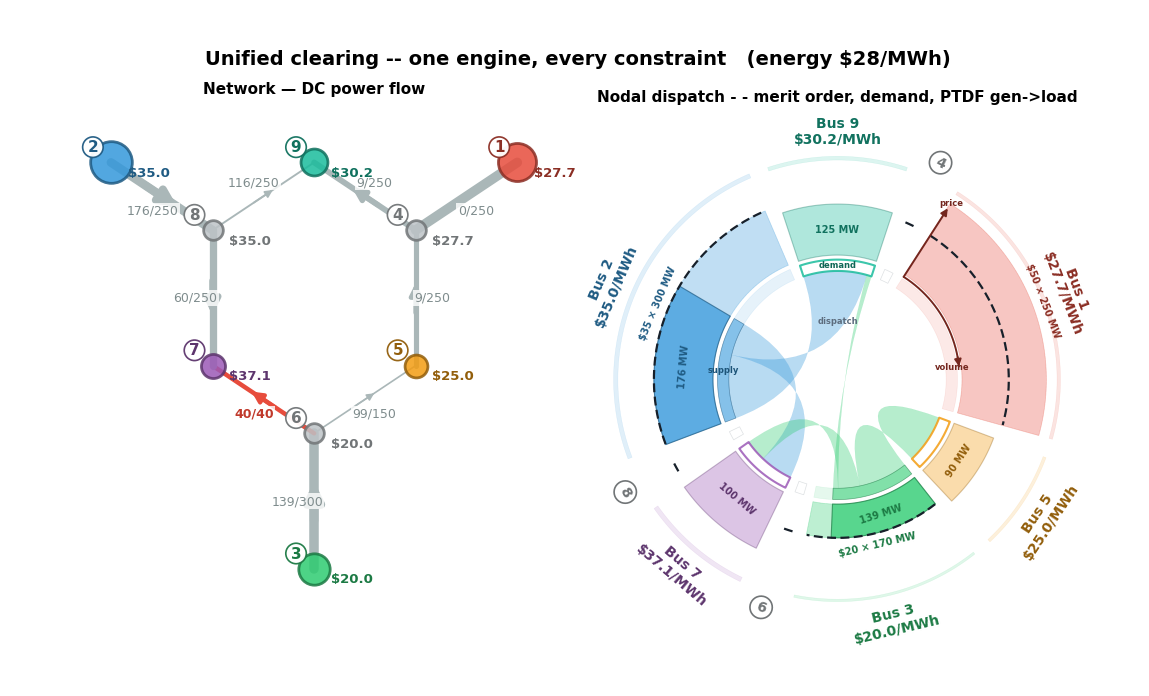

In [25]:
# -- EDIT -- free-form two-market experiment ---------------------------------
RATINGS        = {'line_4': 40.0}
A_BUSES        = ['2', '8', '7', '6', '3']
B_BUSES        = ['1', '9', '4', '5']
A_ACTIVATED    = 'all'        # or a list, e.g. ['line_4'] -> A ignores the rest
B_ACTIVATED    = 'all'
COSTS          = {}           # {'gen_1': 30.0}
LOADS_OVERRIDE = {}           # {'9': 160.0}
E_MW           = 0.0          # scheduled seam interchange A -> B (price-insensitive)
TIE            = ('6', '5')   # (export bus in A, import bus in B)
ACC_MARGIN     = 0.0          # 0 = blind; try 1.0 or 1.25 (one-shot forecast reservation)
TRADE_MW       = 50.0         # participant-initiated trade volume (0 = off)
TRADE_SOURCE   = '3'          # Market A gen bus the trade is sourced at
TRADE_SINK     = '9'          # Market B load bus it serves (full path in both clears)
# ----------------------------------------------------------------------------
net = build_network(RATINGS); pt = compute_ptdf(net, slack_bus='1')
for b, v in LOADS_OVERRIDE.items(): LOADS[b] = v

# Rewire the Section-3 footprint config to the sandbox assignment (drives the
# figures' colours, bands, and monitored sets). Re-run Section 3 to restore.
MKT_DEFS = {'Market A': [str(b) for b in A_BUSES], 'Market B': [str(b) for b in B_BUSES]}
_tmp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, tie_label='seam')
internal = {m: [l for l in pt.lines if _tmp.line_kind(pt, l) == ('internal', m)] for m in MKT_DEFS}
MONITORED_LINES = {m: list(internal[m]) for m in MKT_DEFS}
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='seam')
bus_to_mkt = fp.bus_to_fp; mkt_of = fp.fp_of; MKT_GROUPS = fp.groups(pt); seam_lines = fp.ties

# Configuration map for the sandbox footprints (re-run after editing A_BUSES / B_BUSES).
import matplotlib.patches as _mp
_bcol_sb = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
_figm, _axm = plot_network_topology(
    net, supply_by_bus={}, demand_by_bus={}, bus_colors=_bcol_sb, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=fp.line_colors(pt),
    title='Sandbox footprints -- Market A (purple) / Market B (blue); seams grey')
for _l in seam_lines:
    _b0, _b1 = pt.line_buses[pt.line_idx[_l]]
    _x0, _y0 = COORDS[_b0]; _x1, _y1 = COORDS[_b1]
    _axm.text((_x0 + _x1) / 2, (_y0 + _y1) / 2, f'SEAM {_b0}-{_b1}', fontsize=8, fontweight='bold',
              color='#117A2B', ha='center', va='center',
              bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
_axm.legend(handles=[_mp.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
            loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

A_x = make_engine('Market A', A_BUSES, activated=A_ACTIVATED)
B_x = make_engine('Market B', B_BUSES, activated=B_ACTIVATED)
for eng in (A_x, B_x):
    for g, c in COSTS.items():
        if g in eng.gens: eng.gens[g]['cost'] = c

# Exogenous schedules: the seam interchange (delivered at the tie buses) plus
# the participant trade (FULL PATH: A serves the sink, B receives the source).
def _merge(*ds):
    out = {}
    for d in ds:
        for b, v in (d or {}).items(): out[b] = out.get(b, 0.0) + v
    return {b: v for b, v in out.items() if abs(v) > 1e-9}
exoA = _merge({TIE[0]: -E_MW} if E_MW else None,
              {TRADE_SINK: -TRADE_MW} if TRADE_MW else None)
exoB = _merge({TIE[1]: +E_MW} if E_MW else None,
              {TRADE_SOURCE: +TRADE_MW} if TRADE_MW else None)

offA = offB = None
if ACC_MARGIN > 0:   # reserve the other's blind-forecast component on internal lines
    rA1 = solve_engine_dispatch(pt, A_x, exo=exoA or None)
    rB1 = solve_engine_dispatch(pt, B_x, exo=exoB or None)
    offA = {l: rB1.flow_own[l] * ACC_MARGIN for l in internal['Market A']}
    offB = {l: rA1.flow_own[l] * ACC_MARGIN for l in internal['Market B']}
rA_s = solve_engine_dispatch(pt, A_x, exo=exoA or None, flow_offsets=offA)
rB_s = solve_engine_dispatch(pt, B_x, exo=exoB or None, flow_offsets=offB)

print('A energy', round(rA_s.energy_price, 1), '| B energy', round(rB_s.energy_price, 1))

# ACTUAL wire loading: count generators and loads ONCE. A schedule booked in
# both clears (the full-path trade; the tie pair) has no bus of its own, so
# the booked sum F[A]+F[B] would re-count its path.
def _actual_flows(results):
    p = np.zeros(pt.n_bus)
    for r_ in results:
        for b, mw in r_.gen_by_bus.items():  p[pt.bus_idx[b]] += mw
        for b, mw in r_.load_by_bus.items(): p[pt.bus_idx[b]] -= mw
    return pt.ptdf @ p

f_act = _actual_flows([rA_s, rB_s])
pf_s = physical_flows(pt, [rA_s, rB_s])
pf_s['F_phys'] = np.round(f_act, 1)
pf_s['loading_%'] = np.round(np.abs(f_act) / pf_s['rating'] * 100, 0)
pf_s['overload'] = np.abs(f_act) > pf_s['rating'] + 1e-6
print('overloads (actual):', pf_s[pf_s.overload].index.tolist() or 'none')
if TRADE_MW > 0:
    pays, paid = rA_s.lmp[TRADE_SINK], rB_s.lmp[TRADE_SOURCE]
    cgA = (rA_s.lmp[TRADE_SINK] - rA_s.lmp[TRADE_SOURCE]) * TRADE_MW
    cgB = (rB_s.lmp[TRADE_SINK] - rB_s.lmp[TRADE_SOURCE]) * TRADE_MW
    print(f'participant trade {TRADE_MW:.0f} MW {TRADE_SOURCE}->{TRADE_SINK}: trader pays '
          f'lamA[{TRADE_SINK}] = {pays:.2f}, is paid lamB[{TRADE_SOURCE}] = {paid:.2f}, '
          f'nets {(paid - pays) * TRADE_MW:,.0f} $/h | path congestion kept: '
          f'A {cgA:,.0f}, B {cgB:,.0f} $/h')
display(seam_dual_gap([rA_s, rB_s], pt.buses))
display(pf_s[['from', 'to', 'F[Market A]', 'F[Market B]', 'F_phys', 'rating', 'loading_%', 'overload']])

# -- Positions vs autarky and the unified clearing (Section-8 ledger style) ---
uni_x = MarketEngine(name='Unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                     loads=dict(LOADS), activated_lines='all')
for g, c in COSTS.items():
    if g in uni_x.gens: uni_x.gens[g]['cost'] = c
runi_x = solve_engine_dispatch(pt, uni_x)
# Autarky re-clears the SAME knobs with every cross-boundary schedule removed
# (no seam interchange, no trade); the reservation knob still applies.
offA0 = offB0 = None
if ACC_MARGIN > 0:
    rA_b = solve_engine_dispatch(pt, A_x)
    rB_b = solve_engine_dispatch(pt, B_x)
    offA0 = {l: rB_b.flow_own[l] * ACC_MARGIN for l in internal['Market A']}
    offB0 = {l: rA_b.flow_own[l] * ACC_MARGIN for l in internal['Market B']}
rA_0 = solve_engine_dispatch(pt, A_x, flow_offsets=offA0)
rB_0 = solve_engine_dispatch(pt, B_x, flow_offsets=offB0)

def _positions(rA_, rB_, chgA=0.0, payB=0.0):
    # chgA = what Market A charges the trader (its delivery-bus LMPs x the
    # scheduled MW); payB = what Market B pays the trader (receipt-bus LMPs).
    # Each market's congestion revenue is its settlement RESIDUAL --
    # consumers (+ its trader leg) minus generator revenue -- so every row
    # closes exactly: consumers = gen revenue + congestion + trader.
    out = {}
    for m, eng_, r_, trade_cash in (('Market A', A_x, rA_, +chgA),
                                    ('Market B', B_x, rB_, -payB)):
        cons = sum(r_.lmp[b] * mw for b, mw in eng_.loads.items())
        grev = sum(r_.lmp[str(eng_.gens[g]['bus'])] * mw for g, mw in r_.dispatch.items())
        gcst = sum(eng_.gens[g]['cost'] * mw for g, mw in r_.dispatch.items())
        out[(m, 'consumers')] = -cons
        out[(m, 'gen revenue')] = grev
        out[(m, 'gen profit')] = grev - gcst
        out[(m, 'congestion revenue')] = cons + trade_cash - grev
    out[('Trader', 'profit')] = payB - chgA
    cost = rA_.total_cost + rB_.total_cost
    out[('Total', 'production cost')] = -cost
    out[('Total', 'W vs unified')] = cost - runi_x.total_cost
    return out

def _positions_unified(r_):
    # One pool, one rent: attribute each binding line's rent to the market
    # whose footprint contains it (a binding seam line splits evenly). Under
    # a unified clear any per-market split is an allocation CHOICE -- the
    # congestion-revenue-allocation question in one column.
    rent = {m: 0.0 for m in MKT_DEFS}
    for l, mu in r_.line_dual.items():
        if abs(mu) < 1e-9: continue
        kind = line_kind(pt, l)
        share = abs(mu) * pt.s_nom[pt.line_idx[l]]
        if kind[0] == 'internal': rent[kind[1]] += share
        else:
            for m in MKT_DEFS: rent[m] += share / len(MKT_DEFS)
    out = {}
    for m, eng_ in (('Market A', A_x), ('Market B', B_x)):
        own = [g for g in r_.dispatch if str(uni_x.gens[g]['bus']) in eng_.buses]
        grev = sum(r_.lmp[str(uni_x.gens[g]['bus'])] * r_.dispatch[g] for g in own)
        gcst = sum(uni_x.gens[g]['cost'] * r_.dispatch[g] for g in own)
        out[(m, 'consumers')] = -sum(r_.lmp[b] * mw for b, mw in eng_.loads.items())
        out[(m, 'gen revenue')] = grev
        out[(m, 'gen profit')] = grev - gcst
        out[(m, 'congestion revenue')] = rent[m]
    out[('Trader', 'profit')] = 0.0
    out[('Total', 'production cost')] = -r_.total_cost
    out[('Total', 'W vs unified')] = 0.0
    return out

chgA_s = rA_s.lmp[TIE[0]] * E_MW + rA_s.lmp[TRADE_SINK] * TRADE_MW   # A's delivery legs
payB_s = rB_s.lmp[TIE[1]] * E_MW + rB_s.lmp[TRADE_SOURCE] * TRADE_MW # B's receipt legs
led_s = pd.DataFrame({
    'autarky (no cross-boundary schedule)': _positions(rA_0, rB_0),
    'sandbox arrangement (knobs above)':    _positions(rA_s, rB_s, chgA_s, payB_s),
    'unified clearing':                     _positions_unified(runi_x),
}).T.round(0) + 0.0   # +0.0 kills negative zeros
led_s.columns = pd.MultiIndex.from_tuples(led_s.columns)
f_aut = _actual_flows([rA_0, rB_0])
_over = lambda f: [l for l, x in zip(pt.lines, np.abs(f) > pt.s_nom + 1e-6) if x] or 'none'
print('Positions ($/h; consumer payments negative):')
print(f"actual overloads -- autarky: {_over(f_aut)} | sandbox: "
      f"{pf_s[pf_s.overload].index.tolist() or 'none'} | unified: none")
display(led_s)

# -- Each market's set (network + nodal dispatch), Section-6 conventions:
# the seam interchange as an unpriced block at the tie; the participant trade
# in GREY at the other market's LMP for that bus (= its settlement price).
GRAY = '#8E979E'
supA, demA = to_supply_demand(A_x, rA_s)
supB, demB = to_supply_demand(B_x, rB_s)
segA = segB = None
if E_MW:
    demA[TIE[0]] = demA.get(TIE[0], 0.0) + E_MW
    supB.setdefault(TIE[1], []).append({'unit_id': 'self_schedule', 'price': rB_s.lmp[TIE[1]],
                                        'volume': E_MW, 'capacity': E_MW,
                                        'accepted_volume': E_MW})
def _grey_source(sup_, grey_price, note=True):
    # the source gen's stack STARTS with the grey block (self-schedules clear
    # regardless of price); the unit's remaining capacity offers at its bid.
    taken = 0.0
    for u in sup_.get(TRADE_SOURCE, []):
        take = min(TRADE_MW - taken, u['accepted_volume'])
        u['accepted_volume'] -= take
        u['volume'] = u['capacity'] = u['capacity'] - take
        taken += take
    if note and taken < TRADE_MW - 0.01:
        print(f'NOTE: the bus-{TRADE_SOURCE} unit clears only {taken:.0f} of the '
              f'{TRADE_MW:.0f} MW schedule in this dispatch.')
    sup_[TRADE_SOURCE] = [u for u in sup_.get(TRADE_SOURCE, []) if u['volume'] > 0]
    sup_.setdefault(TRADE_SOURCE, []).insert(0, {'unit_id': 'self_schedule',
        'price': grey_price, 'volume': TRADE_MW, 'capacity': TRADE_MW,
        'accepted_volume': TRADE_MW, 'color': GRAY})
def _sink_seg(total, grey_price, rest_price):
    # the sink load bar SPLITS: grey first slice = the MW the schedule serves.
    return {TRADE_SINK: [{'mw': min(TRADE_MW, total), 'price': grey_price, 'color': GRAY}]
                        + ([{'mw': total - TRADE_MW, 'price': rest_price}]
                           if total - TRADE_MW > 0.01 else [])}
if TRADE_MW > 0:
    _grey_source(supA, rB_s.lmp[TRADE_SOURCE])           # grey @ B's price (= trader paid)
    demA[TRADE_SINK] = demA.get(TRADE_SINK, 0.0) + TRADE_MW
    segA = _sink_seg(demA[TRADE_SINK], rB_s.lmp[TRADE_SINK], rA_s.lmp[TRADE_SINK])
    supB.setdefault(TRADE_SOURCE, []).insert(0, {'unit_id': 'self_schedule',
        'price': rA_s.lmp[TRADE_SOURCE], 'volume': TRADE_MW, 'capacity': TRADE_MW,
        'accepted_volume': TRADE_MW, 'color': GRAY})      # grey @ A's price (= A pays its gen)
    segB = _sink_seg(demB.get(TRADE_SINK, 0.0), rA_s.lmp[TRADE_SINK], rB_s.lmp[TRADE_SINK])
annA = _merge({TIE[0]: -E_MW} if E_MW else None,
              {TRADE_SOURCE: -TRADE_MW} if TRADE_MW else None)
annB = _merge({TIE[1]: +E_MW} if E_MW else None,
              {TRADE_SINK: +TRADE_MW} if TRADE_MW else None)
for eng, r, sd, segs, ann in ((A_x, rA_s, (supA, demA), segA, annA),
                              (B_x, rB_s, (supB, demB), segB, annB)):
    market_figure(net, pt, eng, r, sup_dem=sd, demand_segments=segs,
        exo_sched=ann or None,
        suptitle=f'{eng.name} -- sandbox   (energy ${r.energy_price:.0f}/MWh)')
    plt.show()

# -- Combined set: the wire sees ONE dispatch. Network = the ACTUAL total
# flows (red = genuine overload); wheel = both markets' bars together, each
# bus priced at its HOME market's LMP; the trade stays grey at its
# settlement prices. With a seam interchange the chords show A's surplus
# generation reaching B's loads -- the transfer has no bus of its own.
supC, demC = {}, {}
for eng_, r_ in ((A_x, rA_s), (B_x, rB_s)):
    s_, d_ = to_supply_demand(eng_, r_)
    supC.update(s_); demC.update(d_)
segC = None
if TRADE_MW > 0:
    _grey_source(supC, rB_s.lmp[TRADE_SOURCE], note=False)
    segC = _sink_seg(demC.get(TRADE_SINK, 0.0), rA_s.lmp[TRADE_SINK], rB_s.lmp[TRADE_SINK])
host_lmp = {b: (rA_s if mkt_of(b) == 'Market A' else rB_s).lmp[b] for b in pt.buses}
fig, _ = plot_combined_letter(
    net, supC, demC,
    bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp,
    line_flows={l: float(f) for l, f in zip(pt.lines, f_act)},
    line_widths=susceptance_widths(pt), line_colors=market_line_colors(pt),
    constrained_lines={l for l, f in zip(pt.lines, f_act)
                       if abs(f) > pt.s_nom[pt.line_idx[l]] + 1e-6},
    flows=nodal_plot.compute_ptdf_flows(net, supC, demC),
    lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS),
    show_group_labels=False, demand_segments=segC,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    annotate_roles=True, axis_key=True,
    title_left='Network -- ACTUAL total flows (gens & loads counted once)',
    suptitle='Combined -- the one wire under both dispatches   (each bus at its home LMP)')
plt.show()

# -- Unified set: what one engine over every bus and constraint would do.
supU, demU = to_supply_demand(uni_x, runi_x)
bindU = {l for l, mu in runi_x.line_dual.items() if abs(mu) > 1e-3}
fig, _ = plot_combined_letter(
    net, supU, demU,
    bus_colors=dict(BUS_COLORS), bus_lmps=runi_x.lmp,
    line_flows={l: runi_x.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=bindU,
    flows=nodal_plot.compute_ptdf_flows(net, supU, demU),
    clearing_price=runi_x.energy_price, lmp_line=True,
    annotate_roles=True, axis_key=True,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    suptitle=f'Unified clearing -- one engine, every constraint   '
             f'(energy \${runi_x.energy_price:.0f}/MWh)')
plt.show()

---
*Computation: [`seams_engine.py`](seams_engine.py) (PTDF DC-OPF, dual-derived LMPs).
Network: [`ieee9_network.py`](ieee9_network.py). Plots: [`nodal_plot.py`](nodal_plot.py).
Validated against an independent Egret SCED solution.*